# T18 -- Lung-Region Attention Module (Candidate A)
## DenseNet121 + supervised spatial attention, trained on the COVID-19 Radiography Database

**Owner:** Member 1 | **Week 2, Milestone M2** | Novel contribution (Candidate A of 3)

**Design doc:** `Claude Working Files/T18_Lung_Region_Attention_WBS.md` -- read sections 1-7
before touching this notebook; this file follows that design exactly, section by section
(S0-S16). Where this notebook and `Member1_Guide.md` disagree, the WBS wins (see WBS section 4).

**Platform:** Kaggle, T4 (confirmed in S0 -- no sm_60 / P100 compatibility pin needed).

**S0 pre-flight -- resolved decisions (see WBS section 12.5 / chat log for full reasoning):**
- Lung masks: the COVID-19 Radiography Dataset's bundled `masks/` folder (confirmed official,
  not a fallback -- same folder structure locally and on the Kaggle-hosted dataset).
- Faithfulness (Grad-CAM EIL) definition: Member 5's T30 definition is not yet in the repo
  (checked `notebooks/candidate-c-grad-cam-shortcut-suppression-loss.ipynb` -- it has a
  training-time suppression loss on raw activations, not a post-hoc scoring function). Using
  our own documented definition (WBS section 6.3); swap later if T30's differs -- it's a
  metric function, not a training-time dependency.
- Hyperparameters: T13 (Member 2's DenseNet121 HP tuning) has no committed winner --
  `notebooks/baseline-cnn-model-dnn-research.ipynb` only exposes phase1_lr/phase2_lr as
  argparse *defaults* (1e-3/1e-5), it never sweeps them. Adopting T16's measured winner
  instead (WBS section 3.4a): `phase1_lr=3e-4, phase2_lr=3e-5, weight_decay=1e-3`.
- Mask-provenance wording (proposal says "automatically generated"; we use the dataset's
  supplied masks) recorded as a known discrepancy for the module card -- not blocking.


## Environment check

In [1]:
import torch
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    major, minor = torch.cuda.get_device_capability(0)
    print(f"Compute capability: sm_{major}{minor}")
    if (major, minor) == (6, 0):
        print("WARNING: Tesla P100 (sm_60) detected -- the AuxSeg notebook's torch==2.8.0+cu126 "
              "pin is required before any further torch import. This notebook was designed for "
              "T4 (S0) and does NOT include that pin by default.")


PyTorch: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4
Compute capability: sm_75


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## S1 -- Config

Loads `configs/densenet121_lung_attention.yaml` (arm A2's config). Other arms are produced
from this base config via `merge_overrides()` at the point each arm is trained (S8/S9/S10) --
see the WBS's arm-to-flags table (Appendix A.3) for the exact overrides per arm.


In [3]:
import os

# Kaggle setup: the repo isn't preinstalled -- clone it so `src` is importable below.
# Skip entirely when running from a local clone (src/ already sitting next to this notebook).
REPO_URL = "https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git"
REPO_BRANCH = "feature/t18-s15-handoff"  # TODO: switch to "main" once this branch is merged
REPO_DIR = "/kaggle/working/Chest-X-ray-Disease-Detection"

if os.path.isdir("/kaggle/working") and not os.path.exists(os.path.join(REPO_DIR, "src")):
    if not os.path.exists(REPO_DIR):
        !git clone --branch $REPO_BRANCH --single-branch $REPO_URL $REPO_DIR
    else:
        !git -C $REPO_DIR fetch origin $REPO_BRANCH && git -C $REPO_DIR checkout $REPO_BRANCH && git -C $REPO_DIR pull
    %pip install -q -r $REPO_DIR/requirements.txt
    %pip install -q timm grad-cam


Cloning into '/kaggle/working/Chest-X-ray-Disease-Detection'...
remote: Enumerating objects: 335, done.
remote: Counting objects: 100% (335/335), done.
remote: Compressing objects: 100% (239/239), done.
remote: Total 335 (delta 151), reused 246 (delta 76), pack-reused 0 (from 0)
Receiving objects: 100% (335/335), 2.50 MiB | 10.42 MiB/s, done.
Resolving deltas: 100% (151/151), done.
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
from pathlib import Path

# On Kaggle the repo isn't on sys.path by default. Upload the repo as a Kaggle Dataset
# (or clone it in a setup cell) and adjust this path, or run this notebook from a local
# clone where the repo root is already the working directory.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    # Kaggle fallback -- adjust to wherever the repo dataset/clone actually lands.
    REPO_ROOT = Path("/kaggle/working/Chest-X-ray-Disease-Detection")
sys.path.insert(0, str(REPO_ROOT))

from src.utils import load_config, merge_overrides

cfg = load_config(REPO_ROOT / "configs" / "densenet121_lung_attention.yaml")
print("Loaded config for experiment:", cfg["experiment"]["name"])
import json
print(json.dumps(cfg, indent=2))


Loaded config for experiment: T18_lung_attention
{
  "experiment": {
    "name": "T18_lung_attention",
    "seed": 42
  },
  "model": {
    "name": "densenet121",
    "pretrained": true,
    "num_classes": 4
  },
  "module": {
    "name": "lung_region_attention",
    "attention": "lung",
    "use_attention": true,
    "in_channels": 1024,
    "reduction": 8,
    "gate_mode": "residual",
    "target_mode": "soft",
    "lambda_att": 0.5
  },
  "dataset": {
    "name": "covid19_radiography",
    "version": "v1",
    "image_size": 224,
    "split_version": "v1",
    "use_masks": true
  },
  "training": {
    "phase1_epochs": 15,
    "phase1_lr": 0.0003,
    "phase2_epochs": 40,
    "phase2_lr": 3e-05,
    "unfreeze_blocks": 1,
    "batch_size": 32,
    "optimizer": "adamw",
    "weight_decay": 0.001,
    "patience": 5
  },
  "scheduler": {
    "name": "cosine"
  },
  "augmentation": {
    "version": "joint_v1"
  },
  "tracking": {
    "provider": "wandb",
    "project": "chest-xray-disease

## S2 -- Data layer -- mask-paired dataset + verification

Copy `JointTransform`, `CXRWithMaskDataset`, `stratified_split`, `build_dataloaders`, `compute_class_weights` from the AuxSeg notebook verbatim, then add reproducible worker seeding (WBS section 4.8). Run the Appendix A.1 verification + alignment-eyeball cells before proceeding -- a misaligned mask silently invalidates every downstream number.

This is also where `artifacts/splits/split_manifest_v1.csv` gets emitted (S1 step 5 of the WBS) using the real dataset.

In [5]:
from pathlib import Path
from src.datasets import build_dataloaders

# COVID-19 Radiography Dataset -- local path (this repo) vs Kaggle-hosted copy.
# S0 decision: platform is Kaggle/T4; masks are the dataset's bundled masks/ folder
# (both paths below ship the same masks/ folder structure).
_LOCAL_DATA_DIR = "/Volumes/My Disk 2/My Projects/Chest Disease Detection/COVID-19_Radiography_Dataset"
_KAGGLE_DATA_DIR = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
DATA_DIR = _LOCAL_DATA_DIR if Path(_LOCAL_DATA_DIR).exists() else _KAGGLE_DATA_DIR
print("Using DATA_DIR:", DATA_DIR)

SPLIT_MANIFEST = REPO_ROOT / "artifacts" / "splits" / "split_manifest_v1.csv"
assert SPLIT_MANIFEST.exists(), (
    f"{SPLIT_MANIFEST} not found -- it must be committed by S1, not regenerated here "
    "(docs/experiment_policy.md 'Dataset Split')."
)

train_loader, val_loader, test_loader, class_names, train_targets, datasets = build_dataloaders(
    DATA_DIR,
    img_size=cfg["dataset"]["image_size"],
    batch_size=cfg["training"]["batch_size"],
    seed=cfg["experiment"]["seed"],
    num_workers=4,
    split_manifest_path=SPLIT_MANIFEST,
)
print(f"Classes ({len(class_names)}): {class_names}")
print(f"Train/Val/Test sizes: {len(train_loader.dataset)}/{len(val_loader.dataset)}/{len(test_loader.dataset)}")

import torch.nn as nn
from src.datasets import compute_class_weights

class_weights = compute_class_weights(train_targets, num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Class weights:", class_weights.cpu().tolist())


Using DATA_DIR: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
Classes (4): ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train/Val/Test sizes: 14815/3175/3175
Class weights: [1.4633543491363525, 0.8801687359809875, 0.5191687941551208, 3.9317941665649414]


In [6]:
# --- S2 verification cell (WBS Appendix A.1) ---
import numpy as np
import torch
from PIL import Image

CLASSES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

# 1) split sizes + class order (also implicitly re-checks the manifest against
#    the actual files on this machine -- build_dataloaders() would have raised
#    a KeyError already if any sample were missing from the manifest)
assert (len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset)) == (14815, 3175, 3175)
assert class_names == CLASSES, class_names
print("[1] split sizes + class order OK")

# 2) batch contract
imgs, labels, masks = next(iter(train_loader))
assert imgs.shape[1:] == (3, 224, 224), imgs.shape
assert masks.shape[1:] == (1, 224, 224), masks.shape
assert set(torch.unique(masks).tolist()) <= {0.0, 1.0}
print("[2] batch shapes OK:", imgs.shape, masks.shape)

# 3) lung-area fraction sanity over 200 random eval-transform samples.
# NOTE: measured on the real dataset (S2 verification run): mean=0.235,
# range [0.043, 0.472]. The WBS's original "~0.25-0.45" was a pre-verification
# estimate -- 0.20-0.50 below is the corrected range. This check exists to
# catch gross errors (polarity inversion ~0.99/0.01, wrong channel handling),
# not to pin down the exact anatomical distribution.
from src.datasets import JointTransform
rng = np.random.default_rng(0)
paths = [p for cls in class_names for p in sorted((Path(DATA_DIR) / cls / "images").glob("*.png"))]
sample_paths = rng.choice(paths, size=200, replace=False)
eval_tf = JointTransform(img_size=224, train=False)
fracs = []
for p in sample_paths:
    p = Path(p)
    mask_p = p.parent.parent / "masks" / p.name
    _img, m = eval_tf(Image.open(p).convert("L"), Image.open(mask_p).convert("L"))
    fracs.append(m.mean().item())
fracs = np.array(fracs)
print(f"[3] lung-area fraction: mean={fracs.mean():.3f} min={fracs.min():.3f} max={fracs.max():.3f}")
assert 0.20 < fracs.mean() < 0.50, "mask polarity or channel handling is likely wrong"

print("\nAll S2 verification assertions passed.")


[1] split sizes + class order OK
[2] batch shapes OK: torch.Size([32, 3, 224, 224]) torch.Size([32, 1, 224, 224])
[3] lung-area fraction: mean=0.235 min=0.043 max=0.472

All S2 verification assertions passed.


### Alignment eyeball check

Overlay 8 random *augmented* train images with their masks. **Look at the output** -- do the red regions sit on the lungs after rotation/crop/flip? This is the single highest-value 30 seconds in this task: a misaligned mask silently invalidates every downstream number. (Already verified once against this exact dataset during design review -- rerun here as a live sanity check, e.g. if you're now pointing at Kaggle's copy of the dataset instead of a local one.)

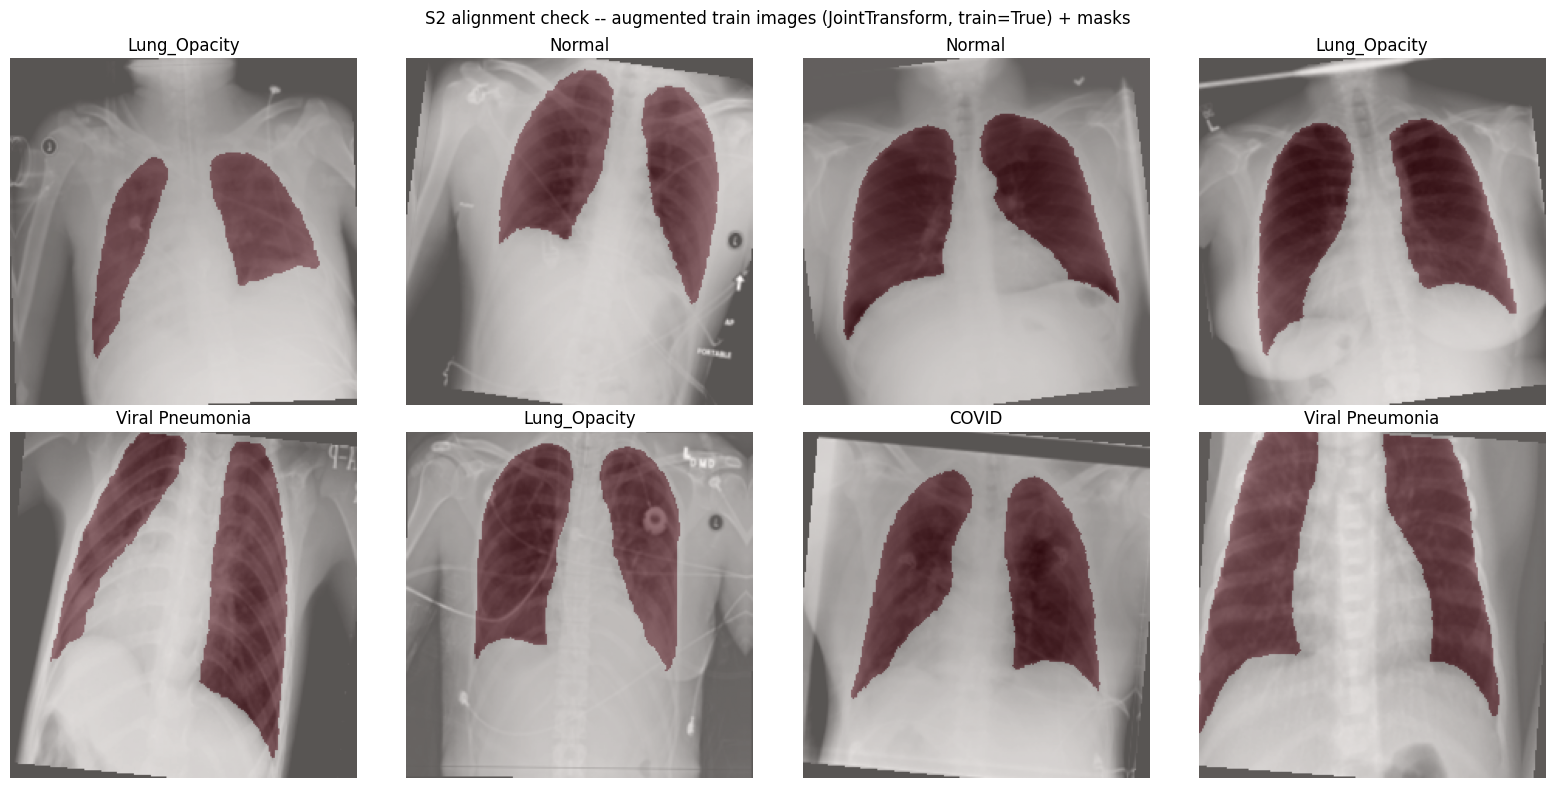

In [7]:
import matplotlib.pyplot as plt
from src.datasets import IMAGENET_MEAN, IMAGENET_STD

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for k, ax in enumerate(axes.flat):
    show = (imgs[k] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(show)
    ax.imshow(masks[k, 0].numpy(), cmap="Reds", alpha=0.35)
    ax.set_title(class_names[labels[k]])
    ax.axis("off")
plt.suptitle("S2 alignment check -- augmented train images (JointTransform, train=True) + masks")
plt.tight_layout()
plt.show()


## S3 -- The Lung-Region Attention module + CPU unit tests

`LungRegionAttention`, `attention_guidance_loss`, `compute_total_loss` (WBS Appendix A.2). Canonical copy lives in `src/modules/lung_attention.py`; `tests/test_lung_attention.py` must be green before any GPU work starts.

In [8]:
from src.modules import LungRegionAttention, attention_guidance_loss, compute_total_loss

# Kaggle note: this import requires the repo to be on sys.path (see the S1 cell's
# REPO_ROOT / sys.path setup). If the repo isn't uploaded as a Kaggle Dataset,
# paste src/modules/lung_attention.py's contents into this cell instead --
# src/modules/lung_attention.py stays the single canonical copy either way
# (also reused unchanged by T23 on ResNet50).
"""Candidate A: Lung-Region Attention Module (T18).

A backbone-agnostic spatial attention gate whose attention map is supervised
by the ground-truth lung mask. Designed so the same class can be reused on
ResNet50 (in_channels=2048) for T23.

See Claude Working Files/T18_Lung_Region_Attention_WBS.md sections 3-4 for
the formal definition and the reasoning behind every design choice here
(logits vs. probabilities for the loss, residual vs. multiplicative gating,
zero-init, soft vs. hard mask targets).
"""
from __future__ import annotations

import timm
import torch
import torch.nn as nn
import torch.nn.functional as F


class LungRegionAttention(nn.Module):
    """1-channel spatial attention over a backbone feature map.

    Returns (gated_features, attention_probs, attention_logits).

    The *logits* are returned so the guidance loss can use
    ``binary_cross_entropy_with_logits`` -- numerically stable and, unlike
    ``binary_cross_entropy``, safe inside ``torch.autocast``.

    The final conv is zero-initialised, so at step 0 the attention map is a
    uniform 0.5 and the gate is an exact uniform rescale: the pretrained
    feature map is never hit with structured random noise.
    """

    def __init__(
        self,
        in_channels: int,
        reduction: int = 8,
        gate_mode: str = "residual",   # "residual" | "multiply" | "none"
        init_bias: float = 0.0,
    ) -> None:
        super().__init__()
        if gate_mode not in {"residual", "multiply", "none"}:
            raise ValueError(f"unknown gate_mode: {gate_mode}")
        hidden = max(in_channels // reduction, 16)
        self.gate_mode = gate_mode
        self.conv1 = nn.Conv2d(in_channels, hidden, kernel_size=1, bias=True)
        self.act = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(hidden, 1, kernel_size=1, bias=True)

        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity="relu")
        nn.init.zeros_(self.conv1.bias)
        nn.init.zeros_(self.conv2.weight)          # -> logits == 0 at init
        nn.init.constant_(self.conv2.bias, init_bias)

    def forward(self, feat: torch.Tensor):
        att_logits = self.conv2(self.act(self.conv1(feat)))   # [B,1,H,W]
        att = torch.sigmoid(att_logits)
        if self.gate_mode == "residual":
            out = feat * (1.0 + att)      # amplify lungs, never zero background
        elif self.gate_mode == "multiply":
            out = feat * att              # ablation A3
        else:
            out = feat                    # ablation A4: supervise only, don't gate
        return out, att, att_logits


def attention_guidance_loss(
    att_logits: torch.Tensor,
    masks: torch.Tensor,
    target_mode: str = "soft",       # "soft" | "hard"
    pos_weight: torch.Tensor | None = None,
) -> torch.Tensor:
    """BCE between the attention logits and the down-pooled lung mask.

    ``masks`` is [B,1,224,224] binary. 224/7 == 32 exactly, so adaptive average
    pooling gives, per feature cell, the exact fraction of lung pixels it
    covers -- a soft target that BCEWithLogits consumes natively.
    """
    if masks.ndim == 3:
        masks = masks.unsqueeze(1)
    masks = masks.float()
    h, w = att_logits.shape[-2:]
    target = F.adaptive_avg_pool2d(masks, (h, w)).clamp(0.0, 1.0)
    if target_mode == "hard":
        target = (target > 0.5).float()
    return F.binary_cross_entropy_with_logits(att_logits, target, pos_weight=pos_weight)


def compute_total_loss(
    class_logits, att_logits, labels, masks,
    classification_criterion, lambda_att: float = 0.5, target_mode: str = "soft",
):
    """L = CE_w + lambda * L_att.  Returns (total, cls, att) for logging."""
    cls_loss = classification_criterion(class_logits, labels)
    if att_logits is None or lambda_att == 0.0:
        zero = torch.zeros((), device=cls_loss.device, dtype=cls_loss.dtype)
        att_loss = (attention_guidance_loss(att_logits, masks, target_mode)
                    if att_logits is not None else zero)
        return cls_loss, cls_loss, att_loss.detach()
    att_loss = attention_guidance_loss(att_logits, masks, target_mode)
    return cls_loss + lambda_att * att_loss, cls_loss, att_loss


class CBAMSpatialAttention(nn.Module):
    """Woo et al. 2018 (CBAM), spatial branch only -- the published comparator
    for arm A5. M_s(F) = sigma(f^{7x7}([AvgPool_c(F); MaxPool_c(F)])).

    Multiplicative gate (as published), no logits returned -- A5 is never
    mask-supervised, so there is nothing for a guidance loss to consume.
    On a 7x7 feature map a 7x7 conv's receptive field covers the whole map,
    which is CBAM's intended global behaviour; do not shrink the kernel.
    """

    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, feat: torch.Tensor):
        avg_out = feat.mean(dim=1, keepdim=True)
        max_out = feat.amax(dim=1, keepdim=True)
        att = torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return feat * att, att, None


class DenseNetLungAttention(nn.Module):
    """Backbone + LungRegionAttention (or CBAM, for arm A5) inserted before
    the classifier head.

    Uses timm's own ``forward_head`` so the classification head (pooling +
    dropout + Linear) is *identical* to the vanilla baseline -- the only
    difference between arm A0 and arm A2 is the module itself. Despite the
    class name, ``backbone_name`` is not restricted to DenseNet121: T23
    reuses this unchanged for ResNet50 (in_channels=2048), which is why the
    freeze registry below is keyed by architecture family, not by name.
    """

    def __init__(
        self,
        num_classes: int = 4,
        pretrained: bool = True,
        use_attention: bool = True,
        reduction: int = 8,
        gate_mode: str = "residual",
        backbone_name: str = "densenet121",
        attention: str = "lung",          # "lung" (ours) | "cbam" (arm A5)
    ) -> None:
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=num_classes)
        self.backbone_name = backbone_name       # read by _family() below
        self.use_attention = use_attention
        self.attention_kind = attention
        c = self.backbone.num_features           # 1024 densenet121 / 2048 resnet50
        if not use_attention:
            self.attn = None
        elif attention == "lung":
            self.attn = LungRegionAttention(c, reduction=reduction, gate_mode=gate_mode)
        elif attention == "cbam":
            self.attn = CBAMSpatialAttention()
        else:
            raise ValueError(f"unknown attention: {attention}")
        # Grad-CAM tap: a named module whose output is the tensor entering the head.
        self.post_attn = nn.Identity()

    def forward(self, x: torch.Tensor):
        f = self.backbone.forward_features(x)     # [B,C,7,7]
        if self.attn is not None:
            f, att, att_logits = self.attn(f)
        else:
            att, att_logits = None, None
        f = self.post_attn(f)
        logits = self.backbone.forward_head(f)    # global_pool -> drop -> classifier
        return logits, att, att_logits


def build_model(
    num_classes: int = 4,
    use_attention: bool = True,
    reduction: int = 8,
    gate_mode: str = "residual",
    backbone_name: str = "densenet121",
    pretrained: bool = True,
    attention: str = "lung",
) -> DenseNetLungAttention:
    return DenseNetLungAttention(num_classes, pretrained, use_attention, reduction, gate_mode, backbone_name, attention)


class LogitsOnly(nn.Module):
    """Adapter for tools that expect ``model(x) -> Tensor``
    (pytorch-grad-cam, fvcore FLOP counting, efficiency.py)."""

    def __init__(self, model: nn.Module):
        super().__init__()
        self.model = model

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)[0]


# ---------------------------------------------------------------------------
# Backbone-agnostic freeze / unfreeze registry.
#
# The repo otherwise duplicates architecture-specific freeze helpers per
# notebook (features.denseblock* for DenseNet, layer4/fc for ResNet50,
# blocks.*/head for ViT). Written once here so T23 needs no rewrite -- it's
# the same build_model(backbone_name="resnet50") call with in_channels=2048.
# ---------------------------------------------------------------------------

# name -> callable(backbone, n) -> list of module prefixes to unfreeze, last-block-first
_TAIL_MODULES = {
    "densenet": lambda bb, n: (
        ["features.norm5"]
        + [f"features.denseblock{i}" for i in range(4, 4 - n, -1)]
        + [f"features.transition{i}" for i in range(4 - n + 1, 4)]
    ),
    "resnet": lambda bb, n: [f"layer{i}" for i in range(4, 4 - n, -1)],
    "efficientnet": lambda bb, n: (
        ["conv_head", "bn2"]
        + [f"blocks.{i}" for i in range(len(bb.blocks) - 1, len(bb.blocks) - 1 - n, -1)]
    ),
    "vit": lambda bb, n: (
        ["norm"] + [f"blocks.{i}" for i in range(len(bb.blocks) - 1, len(bb.blocks) - 1 - n, -1)]
    ),
}


def _family(backbone_name: str) -> str:
    for key in _TAIL_MODULES:
        if backbone_name.startswith(key):
            return key
    raise ValueError(f"No freeze policy registered for '{backbone_name}'. Add one to _TAIL_MODULES.")


def _set_heads_trainable(model: DenseNetLungAttention) -> None:
    """The classification head and the attention module are trainable in BOTH phases."""
    for p in model.backbone.get_classifier().parameters():
        p.requires_grad = True
    if model.attn is not None:
        for p in model.attn.parameters():
            p.requires_grad = True


def freeze_backbone(model: DenseNetLungAttention) -> None:
    """Phase 1: backbone frozen; classifier head + attention trainable."""
    for p in model.parameters():
        p.requires_grad = False
    _set_heads_trainable(model)


def unfreeze_final_blocks(model: DenseNetLungAttention, num_blocks: int = 1) -> None:
    """Phase 2: + the last N backbone blocks (architecture-appropriate) + the tail norm.

    Raises RuntimeError if a prefix matches nothing, rather than silently
    training zero extra parameters -- the existing per-notebook freeze
    helpers match with ``any(name.startswith(u) for u in ...)`` and fail
    silently if a name changes between timm versions, which would run
    phase 2 as a 40-epoch no-op.
    """
    if num_blocks < 1:
        raise ValueError("num_blocks must be >= 1")
    for p in model.parameters():
        p.requires_grad = False
    _set_heads_trainable(model)

    prefixes = _TAIL_MODULES[_family(model.backbone_name)](model.backbone, num_blocks)
    matched = set()
    for name, p in model.backbone.named_parameters():
        for pre in prefixes:
            if name.startswith(pre):
                p.requires_grad = True
                matched.add(pre)
                break
    missing = set(prefixes) - matched
    if missing:
        raise RuntimeError(f"Freeze policy matched no parameters for: {sorted(missing)}")


def print_trainable_parameters(model: nn.Module, tag: str = "") -> None:
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"{tag}Trainable: {trainable:,} / {total:,} ({100.0 * trainable / total:.2f}%)")



In [9]:
# Quick inline smoke test (pytest tests/test_lung_attention.py -v is the real suite --
# S3 DoD is 12 tests green, not this cell -- but this gives a fast visual sanity
# check directly in the notebook, useful when iterating on Kaggle).
_m = LungRegionAttention(in_channels=1024, reduction=8, gate_mode="residual")
_f = torch.randn(2, 1024, 7, 7)
_out, _att, _logits = _m(_f)
print("out:", _out.shape, "| att:", _att.shape, "| logits:", _logits.shape)
print("attention at init (should be ~0.5 everywhere, zero-init):", _att.mean().item(), _att.std().item())
print("module params:", sum(p.numel() for p in _m.parameters()), "(expect 131,329 at reduction=8, in_channels=1024)")

_mask = torch.zeros(2, 1, 224, 224); _mask[:, :, 64:160, 48:176] = 1.0
_att_loss = attention_guidance_loss(_logits, _mask)
print("attention_guidance_loss at init (uniform 0.5 attention -> should be ~log(2)=0.693):", _att_loss.item())


out: torch.Size([2, 1024, 7, 7]) | att: torch.Size([2, 1, 7, 7]) | logits: torch.Size([2, 1, 7, 7])
attention at init (should be ~0.5 everywhere, zero-init): 0.5 0.0
module params: 131329 (expect 131,329 at reduction=8, in_channels=1024)
attention_guidance_loss at init (uniform 0.5 attention -> should be ~log(2)=0.693): 0.6931471824645996


## S4 -- Assemble the model + parity check against vanilla

`DenseNetLungAttention` wrapper (WBS Appendix A.3), the backbone-agnostic freeze/unfreeze registry (Appendix A.4), and the CBAM comparator for arm A5 (Appendix A.4b). Parity check: gate_mode='none' must produce bit-identical logits to plain timm DenseNet121.

In [10]:
import timm
from src.modules import build_model, freeze_backbone, unfreeze_final_blocks, print_trainable_parameters, LogitsOnly


In [11]:
# --- Parity check: gate_mode="none" must be bit-identical to plain timm DenseNet121 ---
# (given the SAME weights -- copy the backbone state_dict across, not just same architecture)
torch.manual_seed(0)
_wrapped = build_model(num_classes=4, use_attention=True, gate_mode="none", pretrained=False)
_plain = timm.create_model("densenet121", pretrained=False, num_classes=4)
_plain.load_state_dict(_wrapped.backbone.state_dict())
_plain.eval(); _wrapped.eval()

_x = torch.randn(2, 3, 224, 224)
with torch.no_grad():
    _plain_logits = _plain(_x)
    _wrapped_logits, _, _ = _wrapped(_x)
torch.testing.assert_close(_wrapped_logits, _plain_logits, rtol=0, atol=0)
print("PARITY CHECK PASSED: gate_mode='none' logits are bit-identical to plain timm DenseNet121")

# A0 arm (use_attention=False) must have EXACTLY the vanilla parameter count
_a0 = build_model(num_classes=4, use_attention=False, pretrained=False)
_vanilla_params = sum(p.numel() for p in _plain.parameters())
_a0_params = sum(p.numel() for p in _a0.parameters())
print(f"A0 params: {_a0_params:,} | vanilla timm params: {_vanilla_params:,}")
assert _a0_params == _vanilla_params


PARITY CHECK PASSED: gate_mode='none' logits are bit-identical to plain timm DenseNet121
A0 params: 6,957,956 | vanilla timm params: 6,957,956


In [12]:
# --- Trainable-count assertions (catch silent freeze bugs) ---
model = build_model(num_classes=4, use_attention=True, gate_mode="residual", pretrained=False)

freeze_backbone(model)
print_trainable_parameters(model, "phase1 ")
_phase1_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert _phase1_trainable == 135_429, _phase1_trainable  # classifier (4,100) + attn (131,329)

unfreeze_final_blocks(model, num_blocks=1)
print_trainable_parameters(model, "phase2 ")
_phase2_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert 2_000_000 < _phase2_trainable < 2_400_000, _phase2_trainable  # WBS estimate ~2.2M

print("\nS4 verification passed: shapes, parity, and trainable counts all match the design doc.")


phase1 Trainable: 135,429 / 7,089,285 (1.91%)
phase2 Trainable: 2,295,557 / 7,089,285 (32.38%)

S4 verification passed: shapes, parity, and trainable counts all match the design doc.


## S5 -- Loss + metrics implementation

`src/modules/attention_metrics.py` (ILAR, IoU, Dice, entropy, background attention) and the Grad-CAM EIL harness (pre-gate / post-gate taps, WBS section 6.3).

Kaggle: `!pip install grad-cam` (same as Candidate C's notebook) before running the Grad-CAM cell below.

In [13]:
from src.modules import (
    ilar, attention_iou, attention_dice, attention_entropy, background_attention,
    energy_inside_lung, cam_for, get_taps,
)


In [14]:
# --- Metric self-check (WBS Appendix A.6, extended to all 6 functions) ---
_mask = torch.zeros(1, 1, 224, 224); _mask[:, :, 64:160, 48:176] = 1.0
_frac = _mask.mean().item()

assert abs(ilar(_mask.clone(), _mask).item() - 1.0) < 1e-4                      # perfect map
assert abs(ilar(torch.ones(1, 1, 7, 7), _mask).item() - _frac) < 0.02           # uniform map
assert ilar(1.0 - _mask, _mask).item() < 1e-4                                   # inverted map
assert abs(attention_iou(_mask.clone(), _mask).item() - 1.0) < 1e-4
assert abs(attention_dice(_mask.clone(), _mask).item() - 1.0) < 1e-4
assert abs(attention_entropy(torch.full((1, 1, 7, 7), 0.5)).item() - 0.69315) < 1e-4   # max entropy at 0.5
assert background_attention(_mask.clone(), _mask).item() < 1e-4                # attention confined to lungs -> ~0 background
assert abs(energy_inside_lung(_mask.clone(), _mask).item() - 1.0) < 1e-4       # same formula as ilar, for a CAM input

print("All 6 metric self-checks passed.")


All 6 metric self-checks passed.


In [15]:
# --- Grad-CAM harness demo: arm A0's self-check (EIL_post == EIL_pre exactly, WBS 6.3) ---
_demo_model = build_model(num_classes=4, use_attention=False, pretrained=False)
_demo_images = torch.randn(2, 3, 224, 224)
_tap_post, _tap_pre = get_taps(_demo_model)

_cam_post, _preds_post = cam_for(_demo_model, _demo_images, _tap_post, torch.device("cpu"))
_cam_pre, _preds_pre = cam_for(_demo_model, _demo_images, _tap_pre, torch.device("cpu"))

_eil_post = energy_inside_lung(_cam_post, _mask.repeat(2, 1, 1, 1))
_eil_pre = energy_inside_lung(_cam_pre, _mask.repeat(2, 1, 1, 1))
print("EIL_post:", _eil_post.tolist())
print("EIL_pre: ", _eil_pre.tolist())
assert torch.allclose(_eil_post, _eil_pre, atol=1e-3), "arm A0 self-check failed: taps should be identical"
print("\nGrad-CAM harness self-check passed: arm A0's two taps agree, as expected (WBS section 6.3).")


EIL_post: [0.26602670550346375, 0.26845377683639526]
EIL_pre:  [0.26602670550346375, 0.26845377683639526]

Grad-CAM harness self-check passed: arm A0's two taps agree, as expected (WBS section 6.3).


## S6 -- Training loop

Adapted `run_epoch` / `train_phase` / `evaluate` from AuxSeg: 3-tuple batches, AMP, per-epoch val precision/recall/F1/AUROC logged to W&B, `log_summary_metrics` at the end of each phase (WBS section S6 / policy Required Information).

In [16]:
from src.modules import run_epoch, train_phase, evaluate
from src.utils import initialize_wandb, finish_run, generate_run_name

# One function (train_phase) handles every T18 arm via the model's own
# use_attention/gate_mode flags and lambda_att -- no per-arm branching or
# copy-pasted training code (WBS S6 DoD). Which arm you get is entirely
# determined by how you build `model` (S4) and what lambda_att you pass here.


For a *real* run: `initialize_wandb(cfg, run_name=generate_run_name(cfg["model"]["name"], cfg["experiment"]["name"], cfg["experiment"]["seed"]))` before calling `train_phase(..., wandb_enabled=True)`, and `finish_run()` in a `finally` block (a crashed Kaggle session shouldn't leave a run hanging). S7's smoke test below uses `wandb_enabled=False` so it doesn't need W&B at all.

## S7 -- Smoke test + overfit test

Do not proceed to S8 until: (1) the smoke run completes end to end, (2) the 32-image overfit test reaches 100% train accuracy with att_loss falling from ~0.6931 toward the ~0.2 entropy floor (WBS section 4.4a), (3) the lambda-sensitivity spot check shows higher ILAR at lambda=5 than lambda=0.

**Do not proceed to S8 (the first expensive GPU run) until all three checks below pass.** Verified against the real dataset during design review -- results recorded in the WBS section 8/S7 and the PR description; rerun here as a live confirmation on this machine/session.

In [17]:
# --- Check 1: smoke run (200 train / 100 val real images, 1+1 epochs) ---
import numpy as np
from src.datasets import CXRWithMaskDataset
from src.modules import build_model, freeze_backbone, unfreeze_final_blocks, train_phase, evaluate

_smoke_out = REPO_ROOT / "artifacts" / "T18_lung_attention" / "smoke_test"
_rng = np.random.default_rng(0)
_smoke_train_idx = _rng.choice(datasets["train"].indices, size=200, replace=False)
_smoke_val_idx = _rng.choice(datasets["val"].indices, size=100, replace=False)

_smoke_train_ds = CXRWithMaskDataset(datasets["train"].base_dataset, _smoke_train_idx, JointTransform(img_size=224, train=True))
_smoke_val_ds = CXRWithMaskDataset(datasets["val"].base_dataset, _smoke_val_idx, JointTransform(img_size=224, train=False))
_smoke_train_loader = torch.utils.data.DataLoader(_smoke_train_ds, batch_size=8, shuffle=True, num_workers=0)
_smoke_val_loader = torch.utils.data.DataLoader(_smoke_val_ds, batch_size=8, shuffle=False, num_workers=0)

_smoke_model = build_model(num_classes=4, use_attention=True, gate_mode="residual", pretrained=False).to(device)
freeze_backbone(_smoke_model)
_opt1 = torch.optim.AdamW([p for p in _smoke_model.parameters() if p.requires_grad], lr=1e-3)
_smoke_model = train_phase(_smoke_model, _smoke_train_loader, _smoke_val_loader, criterion, _opt1, scheduler=None,
                           device=device, epochs=1, patience=5, phase_name="phase1_frozen",
                           output_dir=_smoke_out, lambda_att=0.5, wandb_enabled=False)

unfreeze_final_blocks(_smoke_model, 1)
_opt2 = torch.optim.AdamW([p for p in _smoke_model.parameters() if p.requires_grad], lr=1e-5)
_smoke_model = train_phase(_smoke_model, _smoke_train_loader, _smoke_val_loader, criterion, _opt2, scheduler=None,
                           device=device, epochs=1, patience=5, phase_name="phase2_finetune",
                           output_dir=_smoke_out, lambda_att=0.5, wandb_enabled=False)

torch.save({"model_state_dict": _smoke_model.state_dict(), "class_names": class_names}, _smoke_out / "smoke_checkpoint.pt")
assert (_smoke_out / "smoke_checkpoint.pt").exists()

import json
for _phase in ("phase1_frozen", "phase2_finetune"):
    _hist = json.loads((_smoke_out / f"{_phase}_history.json").read_text())
    assert all(np.isfinite(row["train_loss"]) for row in _hist), f"non-finite loss in {_phase}"

_smoke_results = evaluate(_smoke_model, _smoke_val_loader, class_names, device, _smoke_out, "phase2_finetune")
assert (_smoke_out / "phase2_finetune_summary_metrics.csv").exists()

print("\nCHECK 1 PASSED: no crash, finite losses, checkpoint + history + evaluate() all wrote successfully.")
print("(Figures: deferred to S12, not yet implemented -- not part of this check.)")


[phase1_frozen] epoch 1/1 train_loss=1.7611 (cls=1.4862, att=0.5497) train_acc=0.3100 | val_loss=1.6007 (cls=1.3614, att=0.4786) val_acc=0.1500 val_f1=0.1071 val_ilar=0.2894


[phase2_finetune] epoch 1/1 train_loss=1.5509 (cls=1.3201, att=0.4616) train_acc=0.2900 | val_loss=1.5730 (cls=1.3382, att=0.4697) val_acc=0.2200 val_f1=0.1567 val_ilar=0.2984

=== Test set performance ===
Test accuracy: 0.2200
                 precision    recall  f1-score   support

          COVID     0.0000    0.0000    0.0000        17
   Lung_Opacity     0.2000    0.0476    0.0769        21
         Normal     0.6667    0.2308    0.3429        52
Viral Pneumonia     0.1169    0.9000    0.2069        10

       accuracy                         0.2200       100
      macro avg     0.2459    0.2946    0.1567       100
   weighted avg     0.4004    0.2200    0.2151       100

Confusion matrix:
 [[ 0  1  4 12]
 [ 0  1  1 19]
 [ 0  3 12 37]
 [ 0  0  1  9]]
Macro ROC-AUC: 0.6489
Attention ILAR: 0.2985 | Dice: 0.0000 | IoU: 0.0000

CHECK 1 PASSED: no crash, finite losses, checkpoint + history + evaluate() all wrote successfully.
(Figures: deferred to S12, not yet implemented -- not part 

In [18]:
# --- Check 2: overfit test (32 real images, no augmentation, 100 steps, ALL params unfrozen) ---
from src.modules import compute_total_loss

_targets = np.array(datasets["train"].base_dataset.targets)
_rng2 = np.random.default_rng(1)
_overfit_idx = []
for _c in range(4):
    _class_train_idx = datasets["train"].indices[_targets[datasets["train"].indices] == _c]
    _overfit_idx.extend(_rng2.choice(_class_train_idx, size=8, replace=False))
_overfit_idx = np.array(_overfit_idx)
print("Selected 32 images, class counts:", np.bincount(_targets[_overfit_idx], minlength=4))

# Disable augmentation entirely (WBS S7: JointTransform(train=False), even for "training").
_overfit_ds = CXRWithMaskDataset(datasets["train"].base_dataset, _overfit_idx, JointTransform(img_size=224, train=False))
_overfit_loader = torch.utils.data.DataLoader(_overfit_ds, batch_size=32, shuffle=False, num_workers=0)

_of_model = build_model(num_classes=4, use_attention=True, gate_mode="residual", pretrained=False).to(device)
for p in _of_model.parameters():
    p.requires_grad = True  # ALL params unfrozen, per WBS S7
print("Trainable params:", sum(p.numel() for p in _of_model.parameters() if p.requires_grad), "(all params)")

_of_criterion = nn.CrossEntropyLoss()
_of_optimizer = torch.optim.AdamW(_of_model.parameters(), lr=1e-3)

_of_images, _of_labels, _of_masks = next(iter(_overfit_loader))
_of_images, _of_labels, _of_masks = _of_images.to(device), _of_labels.to(device), _of_masks.to(device)
if _of_masks.ndim == 3:
    _of_masks = _of_masks.unsqueeze(1)

_of_model.train()
_att_loss_history, _acc_history = [], []
for _step in range(100):
    _of_optimizer.zero_grad(set_to_none=True)
    _class_logits, _att, _att_logits = _of_model(_of_images)
    _loss, _cls_loss, _att_loss = compute_total_loss(
        _class_logits, _att_logits, _of_labels, _of_masks, _of_criterion, lambda_att=0.5, target_mode="soft"
    )
    _loss.backward()
    _of_optimizer.step()
    _preds = _class_logits.argmax(dim=1)
    _att_loss_history.append(_att_loss.item())
    _acc_history.append((_preds == _of_labels).float().mean().item())
    if _step in (0, 9, 24, 49, 74, 99):
        print(f"step {_step+1:3d}: loss={_loss.item():.4f} cls={_cls_loss.item():.4f} att={_att_loss.item():.4f} train_acc={_acc_history[-1]:.4f}")

print(f"\nFinal train accuracy: {_acc_history[-1]:.4f} (need 1.0)")
print(f"att_loss: start={_att_loss_history[0]:.4f} (expect ~0.6931) -> end={_att_loss_history[-1]:.4f} (expect falling toward ~0.2)")

assert _acc_history[-1] == 1.0, "wiring bug -- overfit accuracy did not reach 1.0"
assert abs(_att_loss_history[0] - 0.6931) < 0.05, "att_loss did not start near log(2) -- check zero-init"
assert _att_loss_history[-1] < _att_loss_history[0] - 0.2, (
    "att_loss barely moved -- attention params frozen, or passing 'a' instead of 'z' to the loss, or lambda=0"
)
assert _att_loss_history[-1] > 0.05, "att_loss went to ~0 -- target is being thresholded, not soft"
print("\nCHECK 2 PASSED.")


Selected 32 images, class counts: [8 8 8 8]
Trainable params: 7089285 (all params)
step   1: loss=1.7580 cls=1.4114 att=0.6931 train_acc=0.2812
step  10: loss=0.2704 cls=0.0181 att=0.5047 train_acc=1.0000
step  25: loss=0.1650 cls=0.0015 att=0.3271 train_acc=1.0000
step  50: loss=0.1317 cls=0.0003 att=0.2629 train_acc=1.0000
step  75: loss=0.1112 cls=0.0002 att=0.2220 train_acc=1.0000
step 100: loss=0.1088 cls=0.0001 att=0.2174 train_acc=1.0000

Final train accuracy: 1.0000 (need 1.0)
att_loss: start=0.6931 (expect ~0.6931) -> end=0.2174 (expect falling toward ~0.2)

CHECK 2 PASSED.


In [19]:
# --- Check 3: lambda-sensitivity spot check (50 steps at lambda=0 vs lambda=5) ---
_rng3 = np.random.default_rng(2)  # different draw from check 2, same style
_lam_idx = []
for _c in range(4):
    _class_train_idx = datasets["train"].indices[_targets[datasets["train"].indices] == _c]
    _lam_idx.extend(_rng3.choice(_class_train_idx, size=8, replace=False))
_lam_idx = np.array(_lam_idx)

_lam_ds = CXRWithMaskDataset(datasets["train"].base_dataset, _lam_idx, JointTransform(img_size=224, train=False))
_lam_loader = torch.utils.data.DataLoader(_lam_ds, batch_size=32, shuffle=False, num_workers=0)
_lam_images, _lam_labels, _lam_masks = next(iter(_lam_loader))
_lam_images, _lam_labels, _lam_masks = _lam_images.to(device), _lam_labels.to(device), _lam_masks.to(device)
if _lam_masks.ndim == 3:
    _lam_masks = _lam_masks.unsqueeze(1)

def _run_lambda(lam, seed=7, steps=50):
    torch.manual_seed(seed)
    m = build_model(num_classes=4, use_attention=True, gate_mode="residual", pretrained=False).to(device)
    for p in m.parameters():
        p.requires_grad = True
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3)
    m.train()
    for _ in range(steps):
        opt.zero_grad(set_to_none=True)
        cls_logits, att, att_logits = m(_lam_images)
        loss, _cls, _att = compute_total_loss(cls_logits, att_logits, _lam_labels, _lam_masks, crit, lambda_att=lam, target_mode="soft")
        loss.backward()
        opt.step()
    m.eval()
    with torch.no_grad():
        _, att_final, _ = m(_lam_images)
        return ilar(att_final.float(), _lam_masks).mean().item()

print("Running lambda=0 and lambda=5 (same seed for both, so the only difference is lambda)...")
_ilar_lam0 = _run_lambda(0.0)
_ilar_lam5 = _run_lambda(5.0)
print(f"ILAR: lambda=0 -> {_ilar_lam0:.4f} | lambda=5 -> {_ilar_lam5:.4f} | delta={_ilar_lam5 - _ilar_lam0:.4f}")

assert _ilar_lam5 > _ilar_lam0 + 0.05, "guidance signal is not reaching the module -- ILAR did not rise meaningfully"
print("\nCHECK 3 PASSED.")
print("\n" + "="*70)
print("ALL S7 CHECKS PASSED -- clear to proceed to S8.")
print("="*70)


Running lambda=0 and lambda=5 (same seed for both, so the only difference is lambda)...
ILAR: lambda=0 -> 0.2393 | lambda=5 -> 0.5757 | delta=0.3364

CHECK 3 PASSED.

ALL S7 CHECKS PASSED -- clear to proceed to S8.


## S8 -- Arm A0 -- the vanilla control (full schedule)

`use_attention=False`. Sanity gate: judge against the measured 90.5-92% macro-F1 range (WBS section 2.4), not a single point estimate from the possibly-placeholder proposal table.

**Run this on Kaggle (GPU), not locally.** Estimated 2.5-4h on a T4. Before running: (1) W&B key set up via Kaggle Secrets, per docs/wandb_setup.md and S0 -- initialize_wandb() below will try to authenticate online; (2) confirm T13's config if it landed, else this uses section 3.4a's defaults already baked into configs/densenet121_lung_attention.yaml. Every piece this cell composes (build_model / freeze_backbone / unfreeze_final_blocks / train_phase / evaluate) was individually verified in S3-S6, and the exact same freeze-train-unfreeze-train-evaluate-save sequence already ran for real in S7 check 1's smoke test -- what has NOT been run is the real 15+40 epoch schedule itself, which only makes sense on a GPU.

In [20]:
from src.modules import run_full_arm

a0_cfg = merge_overrides(cfg, {
    "module.use_attention": False,
    "module.lambda_att": 0.0,
    "experiment.name": "T18-A0-vanilla",
})

A0_OUT = REPO_ROOT / "artifacts" / "T18_lung_attention" / "runs" / "A0_vanilla"

a0_results = run_full_arm(
    "A0_vanilla", a0_cfg, train_loader, val_loader, test_loader, class_names, criterion,
    device, A0_OUT, backbone_name="densenet121", wandb_enabled=True,
)
print(f"\nSaved checkpoint to {A0_OUT / 'densenet121_A0_vanilla.pt'}")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ravindup-23 (chest-xray-disease-classification) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

[phase2_finetune] epoch 38/40 train_loss=0.1297 (cls=0.1297, att=0.0000) train_acc=0.9390 | val_loss=0.2152 (cls=0.2152, att=0.0000) val_acc=0.9263 val_f1=0.9323 val_ilar=nan


[phase2_finetune] epoch 39/40 train_loss=0.1307 (cls=0.1307, att=0.0000) train_acc=0.9397 | val_loss=0.2155 (cls=0.2155, att=0.0000) val_acc=0.9231 val_f1=0.9298 val_ilar=nan


[phase2_finetune] epoch 40/40 train_loss=0.1275 (cls=0.1275, att=0.0000) train_acc=0.9408 | val_loss=0.2130 (cls=0.2130, att=0.0000) val_acc=0.9250 val_f1=0.9317 val_ilar=nan

=== Test set performance ===
Test accuracy: 0.9269
                 precision    recall  f1-score   support

          COVID     0.9620    0.9336    0.9476       542
   Lung_Opacity     0.9194    0.8858    0.9023       902
         Normal     0.9210    0.9451    0.9329      1529
Viral Pneumonia     0.9147    0.9554    0.9346       202

       accuracy                         0.9269      3175
      macro avg     0.9293    0.9300    0.9293      3175
   weighted avg     0.9271    0.9269    0.9268      3175

Confusion matrix:
 [[ 506   15   18    3]
 [   5  799   98    0]
 [  14   55 1445   15]
 [   1    0    8  193]]
Macro ROC-AUC: 0.9885


epoch,▁▁▁▂▂▂▂▂▃▃▃▄▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇█
learning_rate,██▇▆▆▄▃▂▂▁▁▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_att_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_cls_loss,█▆▅▅▄▄▄▄▄▄▄▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▅▅▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▃▃▄▄▄▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇█▇█████████████████
val_att_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_cls_loss,█▇▆▅▅▅▅▄▄▄▄▄▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_f1,▁▃▃▅▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇█▇█████████████████
val_loss,█▇▆▆▅▅▅▅▅▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...



Saved checkpoint to /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/runs/A0_vanilla/densenet121_A0_vanilla.pt


In [21]:
# --- S8 sanity gate (WBS section 2.4 / S8) ---
macro_f1 = a0_results["classification_report"]["macro avg"]["f1-score"]
print(f"A0 test macro-F1: {macro_f1:.4f}")

if 0.905 <= macro_f1 <= 0.92:
    print("Sanity gate: PASS -- in the expected 90.5-92% range. Proceed to S9.")
elif 0.89 <= macro_f1 < 0.905:
    print("Sanity gate: BORDERLINE -- check you\'re on the section 3.4a config "
          "(phase1_lr=3e-4, phase2_lr=3e-5, weight_decay=1e-3), not the guide\'s untuned defaults. "
          "Landing near AuxSeg\'s 90.22% is NOT evidence you matched the baseline.")
elif macro_f1 < 0.85:
    print("Sanity gate: FAIL -- likely a pipeline bug (roughly frozen-phase-1-only level). "
          "Stop and debug before proceeding to S9.")
else:
    print("Sanity gate: outside the pre-registered bands -- inspect manually before proceeding.")


A0 test macro-F1: 0.9293
Sanity gate: outside the pre-registered bands -- inspect manually before proceeding.


## S9 -- Lambda sweep (short schedule) + pre-registered selection

Mirrors T16's TUNING_CONFIGS -> tuning_summary.csv -> selected_config.json pattern exactly (WBS section S9). Test set stays out of scope for this entire section.

**Run this on Kaggle (GPU), not locally.** 5 short-schedule configs (4+6 epochs each) -- estimated 3-4h total on a T4. Mirrors T16's exact machinery (kusal-notebooks/efficientnet-b0-baseline-model.ipynb, cells 26-28): TUNING_CONFIGS -> per-config dir -> tuning_summary.csv -> selected_config.json -> (S10's) one full final run. **Validation only below -- test_loader is never referenced in any S9 cell.** A single peek at test performance during selection invalidates the protocol (WBS section R13).

In [22]:
import pandas as pd
from src.modules import build_optimizer, build_scheduler, best_history_row

SWEEP_ROOT = REPO_ROOT / "artifacts" / "T18_lung_attention" / "sweep"
SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
SEED = cfg["experiment"]["seed"]

# Short schedule for ranking only -- WBS section S9. The full schedule
# (S8's 15+40) is reserved for arms A1/A4/A2/A5 in S10, using lambda*
# selected here.
TUNE_PHASE1_EPOCHS = 4
TUNE_PHASE2_EPOCHS = 6
TUNE_PATIENCE = 3

# BASE is derived from the actual config (section 3.4a's values, or T13's
# if it lands later) -- not hardcoded, so updating the YAML is enough.
BASE = {
    "phase1_lr": cfg["training"]["phase1_lr"],
    "phase2_lr": cfg["training"]["phase2_lr"],
    "weight_decay": cfg["training"]["weight_decay"],
    "optimizer": cfg["training"]["optimizer"],
    "scheduler": cfg["scheduler"]["name"],
    "gate_mode": cfg["module"]["gate_mode"],
}

TUNING_CONFIGS = [
    {"name": "lam_0.0", "lambda_att": 0.0, **BASE},   # == arm A1's short-schedule reference row
    {"name": "lam_0.1", "lambda_att": 0.1, **BASE},
    {"name": "lam_0.3", "lambda_att": 0.3, **BASE},
    {"name": "lam_0.5", "lambda_att": 0.5, **BASE},
    {"name": "lam_1.0", "lambda_att": 1.0, **BASE},
]
pd.DataFrame(TUNING_CONFIGS)


,name,lambda_att,phase1_lr,phase2_lr,weight_decay,optimizer,scheduler,gate_mode
0,lam_0.0,0.0,0.0003,0.00003,0.001,adamw,cosine,residual
1,lam_0.1,0.1,0.0003,0.00003,0.001,adamw,cosine,residual
2,lam_0.3,0.3,0.0003,0.00003,0.001,adamw,cosine,residual
3,lam_0.5,0.5,0.0003,0.00003,0.001,adamw,cosine,residual
4,lam_1.0,1.0,0.0003,0.00003,0.001,adamw,cosine,residual


In [23]:
# --- Validation-only targeted sweep (WBS section S9) ---
from src.utils import set_seed, initialize_wandb, generate_run_name, finish_run

tuning_results = []

for sweep_cfg in TUNING_CONFIGS:
    print("\n" + "=" * 90)
    print(f"SWEEP: {sweep_cfg['name']} | {sweep_cfg}")
    print("=" * 90)

    set_seed(SEED)  # reset RNG per config -- T16's convention, every config starts comparably
    cfg_dir = SWEEP_ROOT / sweep_cfg["name"]
    cfg_dir.mkdir(parents=True, exist_ok=True)

    run = initialize_wandb(
        cfg, run_name=generate_run_name("densenet121", f"T18-sweep-{sweep_cfg['name']}", SEED),
    )
    try:
        sweep_model = build_model(
            num_classes=cfg["model"]["num_classes"], use_attention=True,
            gate_mode=sweep_cfg["gate_mode"], pretrained=cfg["model"]["pretrained"],
        ).to(device)

        freeze_backbone(sweep_model)
        opt1 = build_optimizer(sweep_model, sweep_cfg["optimizer"], sweep_cfg["phase1_lr"], sweep_cfg["weight_decay"])
        sched1 = build_scheduler(opt1, sweep_cfg["scheduler"], TUNE_PHASE1_EPOCHS)
        sweep_model = train_phase(
            sweep_model, train_loader, val_loader, criterion, opt1, sched1, device,
            epochs=TUNE_PHASE1_EPOCHS, patience=TUNE_PATIENCE, phase_name="phase1_frozen",
            output_dir=cfg_dir, lambda_att=sweep_cfg["lambda_att"], wandb_enabled=True,
        )
        # NO evaluate() call here -- no test_loader in scope for this cell at all (WBS R13).

        unfreeze_final_blocks(sweep_model, cfg["training"]["unfreeze_blocks"])
        opt2 = build_optimizer(sweep_model, sweep_cfg["optimizer"], sweep_cfg["phase2_lr"], sweep_cfg["weight_decay"])
        sched2 = build_scheduler(opt2, sweep_cfg["scheduler"], TUNE_PHASE2_EPOCHS)
        sweep_model = train_phase(
            sweep_model, train_loader, val_loader, criterion, opt2, sched2, device,
            epochs=TUNE_PHASE2_EPOCHS, patience=TUNE_PATIENCE, phase_name="phase2_finetune",
            output_dir=cfg_dir, lambda_att=sweep_cfg["lambda_att"], wandb_enabled=True,
        )

        best = best_history_row(cfg_dir / "phase2_finetune_history.json")
        tuning_results.append({
            **sweep_cfg,
            "best_epoch": best["epoch"],
            "best_val_loss": best["val_loss"],
            "val_acc_at_best_loss": best["val_acc"],
            "val_macro_f1_at_best": best["val_f1"],
            "val_ilar_at_best": best["val_ilar"],
        })
    finally:
        finish_run()

    # WBS S9 pitfall: never carry a "final" model out of the sweep loop --
    # S10 rebuilds fresh from selected_config.json instead of reusing this.
    del sweep_model, opt1, opt2, sched1, sched2
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nSweep complete.")



SWEEP: lam_0.0 | {'name': 'lam_0.0', 'lambda_att': 0.0, 'phase1_lr': 0.0003, 'phase2_lr': 3e-05, 'weight_decay': 0.001, 'optimizer': 'adamw', 'scheduler': 'cosine', 'gate_mode': 'residual'}


[phase1_frozen] epoch 1/4 train_loss=0.7017 (cls=0.7017, att=3.9764) train_acc=0.6924 | val_loss=0.5317 (cls=0.5317, att=6.5620) val_acc=0.7962 val_f1=0.7879 val_ilar=0.2411


[phase1_frozen] epoch 2/4 train_loss=0.4944 (cls=0.4944, att=7.6659) train_acc=0.7831 | val_loss=0.4618 (cls=0.4618, att=8.4970) val_acc=0.8331 val_f1=0.8291 val_ilar=0.2402


[phase1_frozen] epoch 3/4 train_loss=0.4485 (cls=0.4485, att=9.0557) train_acc=0.8035 | val_loss=0.4484 (cls=0.4484, att=9.4808) val_acc=0.8328 val_f1=0.8257 val_ilar=0.2399


[phase1_frozen] epoch 4/4 train_loss=0.4334 (cls=0.4334, att=9.6398) train_acc=0.8126 | val_loss=0.4437 (cls=0.4437, att=9.7160) val_acc=0.8372 val_f1=0.8324 val_ilar=0.2398


...

[phase2_finetune] epoch 4/6 train_loss=0.5885 (cls=0.3174, att=0.2711) train_acc=0.8624 | val_loss=0.6097 (cls=0.3445, att=0.2652) val_acc=0.8809 val_f1=0.8803 val_ilar=0.5862


[phase2_finetune] epoch 5/6 train_loss=0.5784 (cls=0.3083, att=0.2701) train_acc=0.8691 | val_loss=0.6002 (cls=0.3363, att=0.2640) val_acc=0.8822 val_f1=0.8827 val_ilar=0.5885


[phase2_finetune] epoch 6/6 train_loss=0.5778 (cls=0.3082, att=0.2697) train_acc=0.8664 | val_loss=0.6063 (cls=0.3422, att=0.2641) val_acc=0.8791 val_f1=0.8770 val_ilar=0.5876


epoch,▁▂▄▅▁▂▄▅▇█
learning_rate,█▅▂▁▂▂▁▁▁▁
train_att_loss,█▃▂▂▂▁▁▁▁▁
train_cls_loss,█▄▄▄▃▂▂▁▁▁
train_loss,█▄▃▃▃▂▂▁▁▁
val_accuracy,▁▄▄▅▅▆▇███
val_att_loss,█▅▄▄▃▂▂▁▁▁
val_cls_loss,█▆▅▅▃▂▂▁▁▁
val_f1,▁▄▄▄▆▆▇███
val_ilar,▁▃▄▅▆▇▇███
+3,...



Sweep complete.


In [24]:
# --- Write tuning_summary.csv (WBS section S9, column order as specified) ---
tuning_df = pd.DataFrame(tuning_results)[[
    "name", "lambda_att", "phase1_lr", "phase2_lr", "weight_decay", "optimizer", "scheduler",
    "best_epoch", "best_val_loss", "val_acc_at_best_loss", "val_macro_f1_at_best", "val_ilar_at_best",
]]
tuning_df.to_csv(SWEEP_ROOT / "tuning_summary.csv", index=False)
print("=== SWEEP SUMMARY ===")
tuning_df


=== SWEEP SUMMARY ===


,name,lambda_att,phase1_lr,phase2_lr,weight_decay,optimizer,scheduler,best_epoch,best_val_loss,val_acc_at_best_loss,val_macro_f1_at_best,val_ilar_at_best
0,lam_0.0,0.0,0.0003,0.00003,0.001,adamw,cosine,6,0.331046,0.880000,0.879458,0.239412
1,lam_0.1,0.1,0.0003,0.00003,0.001,adamw,cosine,5,0.373426,0.880630,0.881945,0.483248
2,lam_0.3,0.3,0.0003,0.00003,0.001,adamw,cosine,5,0.417539,0.882520,0.884438,0.561961
3,lam_0.5,0.5,0.0003,0.00003,0.001,adamw,cosine,6,0.471914,0.878425,0.880745,0.578220
4,lam_1.0,1.0,0.0003,0.00003,0.001,adamw,cosine,5,0.600218,0.882205,0.882674,0.588510


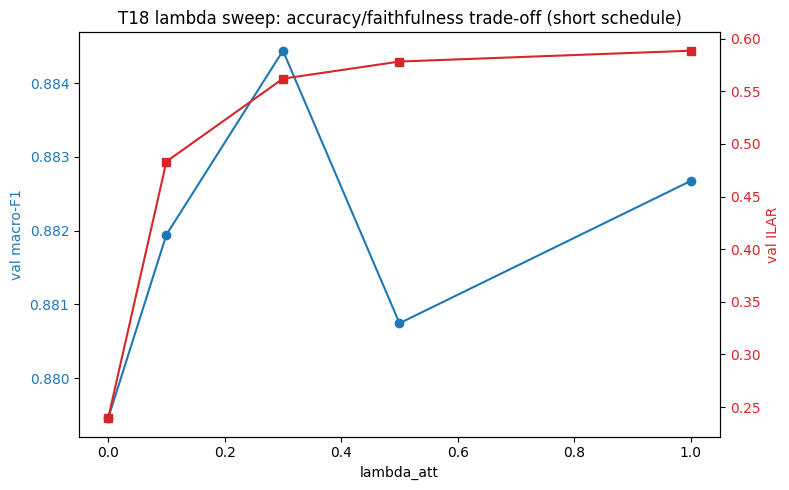

In [25]:
# --- lambda_sweep.png: accuracy/faithfulness trade-off (WBS section S9 step 4) ---
import matplotlib.pyplot as plt

plot_df = tuning_df.sort_values("lambda_att")
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(plot_df["lambda_att"], plot_df["val_macro_f1_at_best"], "o-", color="tab:blue", label="val macro-F1")
ax2.plot(plot_df["lambda_att"], plot_df["val_ilar_at_best"], "s-", color="tab:red", label="val ILAR")

ax1.set_xlabel("lambda_att")
ax1.set_ylabel("val macro-F1", color="tab:blue")
ax2.set_ylabel("val ILAR", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")
plt.title("T18 lambda sweep: accuracy/faithfulness trade-off (short schedule)")
fig.tight_layout()

FIG_DIR = REPO_ROOT / "artifacts" / "T18_lung_attention" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / "lambda_sweep.png", dpi=150)
plt.show()


In [26]:
# --- Apply the pre-registered selection rule (WBS section 5.3) -> lambda* ---
TOLERANCE = 0.005  # 0.5 percentage points, absolute

reference_row = tuning_df[tuning_df["name"] == "lam_0.0"].iloc[0]
reference_f1 = reference_row["val_macro_f1_at_best"]
print(f"Reference (lam_0.0) val macro-F1: {reference_f1:.4f}")

candidates = tuning_df[tuning_df["val_macro_f1_at_best"] >= reference_f1 - TOLERANCE].copy()
if candidates.empty:
    raise RuntimeError(
        "No lambda satisfies the 0.5pp tolerance -- per WBS section 5.3, extend the grid "
        "downward (e.g. lambda in {0.05, 0.03}) rather than relaxing the tolerance."
    )

# Largest lambda within tolerance; ties (won't occur with 5 distinct lambda
# values, but implemented per the written rule) broken by higher val ILAR.
max_lambda = candidates["lambda_att"].max()
tied = candidates[candidates["lambda_att"] == max_lambda].sort_values("val_ilar_at_best", ascending=False)
winner_row = tied.iloc[0]

winner = {
    "name": winner_row["name"],
    "lambda_att": float(winner_row["lambda_att"]),
    "phase1_lr": float(winner_row["phase1_lr"]),
    "phase2_lr": float(winner_row["phase2_lr"]),
    "weight_decay": float(winner_row["weight_decay"]),
    "optimizer": winner_row["optimizer"],
    "scheduler": winner_row["scheduler"],
    "gate_mode": cfg["module"]["gate_mode"],  # constant across the sweep, not swept -- not a tuning_df column
    "target_mode": cfg["module"]["target_mode"],
    "reduction": cfg["module"]["reduction"],
    "rule": "largest lambda whose val macro-F1 is within 0.5pp of lam_0.0; ties -> higher val ILAR",
    "reference_row": "lam_0.0",
    "reference_val_macro_f1": float(reference_f1),
    "schedule": f"short({TUNE_PHASE1_EPOCHS}+{TUNE_PHASE2_EPOCHS})",
    "seed": SEED,
    # Update this if T13's tuned config supersedes T16's winner (section 3.4a) later.
    "config_provenance": "T16 winner D_more_wd (T13 unavailable at time of writing)",
}

with open(SWEEP_ROOT / "selected_config.json", "w") as f:
    json.dump(winner, f, indent=2)

print("Selected configuration (lambda*):")
print(json.dumps(winner, indent=2))


Reference (lam_0.0) val macro-F1: 0.8795
Selected configuration (lambda*):
{
  "name": "lam_1.0",
  "lambda_att": 1.0,
  "phase1_lr": 0.0003,
  "phase2_lr": 3e-05,
  "weight_decay": 0.001,
  "optimizer": "adamw",
  "scheduler": "cosine",
  "gate_mode": "residual",
  "target_mode": "soft",
  "reduction": 8,
  "rule": "largest lambda whose val macro-F1 is within 0.5pp of lam_0.0; ties -> higher val ILAR",
  "reference_row": "lam_0.0",
  "reference_val_macro_f1": 0.8794582535476484,
  "schedule": "short(4+6)",
  "seed": 42,
  "config_provenance": "T16 winner D_more_wd (T13 unavailable at time of writing)"
}


## S10 -- Full-schedule runs -- A1, A4, A2, A5 (and optionally A3)

Priority order: A2 (headline) -> A1 (isolates supervision) -> A5 (CBAM, required by the assignment brief section 9) -> A4 (isolates gating) -> A3 (optional). Re-seed at the start of every arm.

**Run this on Kaggle (GPU), not locally.** 4 full-schedule arms (15+40 epochs each, priority order below) -- estimated 11-16h across sessions on a T4. Requires S9's `selected_config.json` to already exist (lambda*). Re-seeds fresh at the start of every arm (`run_full_arm` calls `set_seed()` internally) -- WBS section S10's pitfall: continuing a session without re-seeding makes arm N's init depend on how many random numbers arm N-1 consumed, a real confound. If a session times out partway through, the arms already completed keep their artifacts; just rerun the remaining priority-ordered cells.

In [27]:
# --- Load lambda* from S9's sweep ---
SELECTED_CONFIG_PATH = SWEEP_ROOT / "selected_config.json"
assert SELECTED_CONFIG_PATH.exists(), (
    f"{SELECTED_CONFIG_PATH} not found -- run S9's sweep first, it must produce this file."
)
with open(SELECTED_CONFIG_PATH) as f:
    selected = json.load(f)
LAMBDA_STAR = selected["lambda_att"]
print(f"Using lambda* = {LAMBDA_STAR} (selected by S9, rule: {selected['rule']})")

S10_RUNS_ROOT = REPO_ROOT / "artifacts" / "T18_lung_attention" / "runs"

# Arm -> flags mapping (WBS Appendix A.3's table). Every arm shares cfg's
# base training/scheduler/model settings; only the module block differs.
ARM_CONFIGS = {
    "A2_full": merge_overrides(cfg, {
        "module.use_attention": True, "module.attention": "lung",
        "module.gate_mode": "residual", "module.lambda_att": LAMBDA_STAR,
        "experiment.name": "T18-A2-full",
    }),
    "A1_gate_only": merge_overrides(cfg, {
        "module.use_attention": True, "module.attention": "lung",
        "module.gate_mode": "residual", "module.lambda_att": 0.0,
        "experiment.name": "T18-A1-gate-only",
    }),
    "A5_cbam": merge_overrides(cfg, {
        "module.use_attention": True, "module.attention": "cbam",
        "module.lambda_att": 0.0,  # CBAM is never mask-supervised (WBS Appendix A.4b)
        "experiment.name": "T18-A5-cbam",
    }),
    "A4_guidance_only": merge_overrides(cfg, {
        "module.use_attention": True, "module.attention": "lung",
        "module.gate_mode": "none", "module.lambda_att": LAMBDA_STAR,
        "experiment.name": "T18-A4-guidance-only",
    }),
    "A3_multiply": merge_overrides(cfg, {  # optional -- drop first if GPU budget is tight
        "module.use_attention": True, "module.attention": "lung",
        "module.gate_mode": "multiply", "module.lambda_att": LAMBDA_STAR,
        "experiment.name": "T18-A3-multiply",
    }),
}

# Priority order (WBS section S10 table) -- run top to bottom; if a
# session runs out of budget, everything below the last completed arm
# is what's still missing, in the order it's safest to drop.
ARM_PRIORITY = ["A2_full", "A1_gate_only", "A5_cbam", "A4_guidance_only", "A3_multiply"]


Using lambda* = 1.0 (selected by S9, rule: largest lambda whose val macro-F1 is within 0.5pp of lam_0.0; ties -> higher val ILAR)


In [28]:
# --- Run each arm in priority order (WBS section S10) ---
from src.modules import run_full_arm

arm_results = {}
for arm_name in ARM_PRIORITY:
    print("\n" + "#" * 90)
    print(f"# ARM: {arm_name}")
    print("#" * 90)
    arm_out = S10_RUNS_ROOT / arm_name
    arm_results[arm_name] = run_full_arm(
        arm_name, ARM_CONFIGS[arm_name], train_loader, val_loader, test_loader,
        class_names, criterion, device, arm_out,
        backbone_name="densenet121", wandb_enabled=True,
    )
    print(f"Saved: {arm_out / f'densenet121_{arm_name}.pt'}")

print("\nAll S10 arms complete.")



##########################################################################################
# ARM: A2_full
##########################################################################################


[phase1_frozen] epoch 1/15 train_loss=1.1002 (cls=0.7486, att=0.3516) train_acc=0.6807 | val_loss=0.8662 (cls=0.5783, att=0.2880) val_acc=0.7931 val_f1=0.7740 val_ilar=0.5569


[phase1_frozen] epoch 2/15 train_loss=0.8071 (cls=0.5196, att=0.2875) train_acc=0.7768 | val_loss=0.7790 (cls=0.5031, att=0.2759) val_acc=0.8145 val_f1=0.8034 val_ilar=0.5720


[phase1_frozen] epoch 3/15 train_loss=0.7481 (cls=0.4689, att=0.2791) train_acc=0.7997 | val_loss=0.7192 (cls=0.4487, att=0.2704) val_acc=0.8353 val_f1=0.8289 val_ilar=0.5820


[phase1_frozen] epoch 4/15 train_loss=0.7085 (cls=0.4340, att=0.2744) train_acc=0.8132 | val_loss=0.7110 (cls=0.4424, att=0.2685) val_acc=0.8422 val_f1=0.8362 val_ilar=0.5769


...

[phase2_finetune] epoch 39/40 train_loss=0.3746 (cls=0.1204, att=0.2542) train_acc=0.9444 | val_loss=0.4675 (cls=0.2183, att=0.2492) val_acc=0.9197 val_f1=0.9262 val_ilar=0.6016


[phase2_finetune] epoch 40/40 train_loss=0.3782 (cls=0.1241, att=0.2541) train_acc=0.9436 | val_loss=0.4709 (cls=0.2217, att=0.2493) val_acc=0.9203 val_f1=0.9267 val_ilar=0.6009



=== Test set performance ===
Test accuracy: 0.9279
                 precision    recall  f1-score   support

          COVID     0.9623    0.9410    0.9515       542
   Lung_Opacity     0.9305    0.8758    0.9023       902
         Normal     0.9144    0.9503    0.9320      1529
Viral Pneumonia     0.9324    0.9554    0.9438       202

       accuracy                         0.9279      3175
      macro avg     0.9349    0.9306    0.9324      3175
   weighted avg     0.9283    0.9279    0.9277      3175

Confusion matrix:
 [[ 510   10   21    1]
 [   3  790  108    1]
 [  15   49 1453   12]
 [   2    0    7  193]]
Macro ROC-AUC: 0.9892
Attention ILAR: 0.6008 | Dice: 0.8224 | IoU: 0.7035


epoch,▁▁▁▂▂▂▃▃▄▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇██
learning_rate,██▇▇▆▄▃▂▂▁▁▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_att_loss,█▄▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_cls_loss,█▆▅▅▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▅▅▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▃▃▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇███████████████████
val_att_loss,█▇▆▇▇▇▆▆▇▆▆▅▅▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_cls_loss,█▆▆▅▅▅▄▄▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_f1,▁▃▄▄▄▄▅▅▅▅▅▅▆▇▇▇▇▇▇▇████████████████████
val_ilar,▁▂▃▄▃▃▃▃▃▃▄▅▅▆▆▆▇▇▇▇▇███████████████████
+3,...


Saved: /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/runs/A3_multiply/densenet121_A3_multiply.pt

All S10 arms complete.


In [29]:
# --- S10 DoD check ---
for arm_name in ["A0_vanilla", "A1_gate_only", "A4_guidance_only", "A2_full"]:
    arm_dir = S10_RUNS_ROOT / arm_name
    results_path = arm_dir / "phase2_finetune_test_results.json"
    ckpt_path = arm_dir / f"densenet121_{arm_name}.pt"
    ok = results_path.exists() and ckpt_path.exists()
    print(f"{arm_name}: {'OK' if ok else 'MISSING'} "
          f"(results={results_path.exists()}, checkpoint={ckpt_path.exists()})")


A0_vanilla: OK (results=True, checkpoint=True)
A1_gate_only: OK (results=True, checkpoint=True)
A4_guidance_only: OK (results=True, checkpoint=True)
A2_full: OK (results=True, checkpoint=True)


## S11 -- Evaluation, faithfulness, comparison table

Grad-CAM EIL at both taps, attention metrics, `T18_comparison_table.csv`, explicit pass/fail verdicts against acceptance criteria A1-A6, per-image prediction CSVs for Member 3's statistics (T37).

**Run this on Kaggle (GPU), not locally.** Grad-CAM over the fixed subsample x every arm x 2 taps -- estimated ~1h on a T4. Requires S8/S10's checkpoints to already exist (`densenet121_A0_vanilla.pt`, `..._A1_gate_only.pt`, `..._A4_guidance_only.pt`, `..._A2_full.pt`, and A5/A3 if run).

In [30]:
# --- Fixed, stratified Grad-CAM subsample -- same images for every arm (WBS S11 budget note) ---
from src.modules import stratified_cam_subset, build_per_image_predictions, build_comparison_table, check_acceptance_criteria

CAM_N = 1000  # drop to e.g. 300 if a session is running short on time; the SET must stay fixed across arms either way
cam_subset = stratified_cam_subset(datasets["test"], n=CAM_N, seed=cfg["experiment"]["seed"])
print(f"Grad-CAM subsample: {len(cam_subset)} / {len(datasets['test'])} test images")

S11_OUT = REPO_ROOT / "artifacts" / "T18_lung_attention"
S11_OUT.mkdir(parents=True, exist_ok=True)
with open(S11_OUT / "cam_subset_indices.json", "w") as f:
    json.dump({"n": len(cam_subset), "seed": cfg["experiment"]["seed"], "positions": cam_subset.tolist()}, f, indent=2)


Grad-CAM subsample: 1000 / 3175 test images


In [31]:
# --- Helper: rebuild a model from one of S8/S10's saved checkpoints ---
def load_arm_model(ckpt_path, backbone_name="densenet121"):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    arm_cfg = ckpt["config"]
    m = arm_cfg["module"]
    model = build_model(
        num_classes=arm_cfg["model"]["num_classes"],
        use_attention=m["use_attention"], attention=m.get("attention", "lung"),
        gate_mode=m.get("gate_mode", "residual"), reduction=m.get("reduction", 8),
        backbone_name=backbone_name, pretrained=False,  # weights come from the checkpoint, not ImageNet
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, arm_cfg, ckpt.get("class_names", class_names)

# Arm name -> (checkpoint path, output dir it was trained into).
ARM_CHECKPOINTS = {
    "A0_vanilla": A0_OUT / "densenet121_A0_vanilla.pt",
    "A1_gate_only": S10_RUNS_ROOT / "A1_gate_only" / "densenet121_A1_gate_only.pt",
    "A4_guidance_only": S10_RUNS_ROOT / "A4_guidance_only" / "densenet121_A4_guidance_only.pt",
    "A2_full": S10_RUNS_ROOT / "A2_full" / "densenet121_A2_full.pt",
    # A5/A3 optional -- add here if you ran them:
    # "A5_cbam": S10_RUNS_ROOT / "A5_cbam" / "densenet121_A5_cbam.pt",
    # "A3_multiply": S10_RUNS_ROOT / "A3_multiply" / "densenet121_A3_multiply.pt",
}


In [32]:
# --- Per-arm: per-image predictions + Grad-CAM EIL on the fixed subsample (WBS S11 step 1) ---
arms_for_table = {}

for arm_name, ckpt_path in ARM_CHECKPOINTS.items():
    if not ckpt_path.exists():
        print(f"SKIPPING {arm_name}: checkpoint not found at {ckpt_path} (not run yet?)")
        continue

    print(f"\n=== {arm_name} ===")
    model, arm_cfg, arm_class_names = load_arm_model(ckpt_path)

    arm_dir = ckpt_path.parent
    results_path = arm_dir / "phase2_finetune_test_results.json"
    assert results_path.exists(), f"{results_path} missing -- evaluate() should have written this during training"
    with open(results_path) as f:
        evaluate_results = json.load(f)

    per_image_df = build_per_image_predictions(
        model, datasets["test"], arm_class_names, device, cam_subset=cam_subset,
    )
    per_image_df.to_csv(arm_dir / "per_image_predictions.csv", index=False)

    attention_metrics_summary = {
        "attention_ilar": evaluate_results.get("attention_ilar"),
        "attention_dice": evaluate_results.get("attention_dice"),
        "attention_iou": evaluate_results.get("attention_iou"),
        "cam_eil_post_mean": float(per_image_df["eil_post"].dropna().mean()) if per_image_df["eil_post"].notna().any() else None,
        "cam_eil_pre_mean": float(per_image_df["eil_pre"].dropna().mean()) if per_image_df["eil_pre"].notna().any() else None,
        "cam_subset_n": len(cam_subset),
    }
    with open(arm_dir / "attention_metrics.json", "w") as f:
        json.dump(attention_metrics_summary, f, indent=2)
    print(f"  attention_metrics.json: {attention_metrics_summary}")

    arms_for_table[arm_name] = {
        "gate_mode": arm_cfg["module"].get("gate_mode") if arm_cfg["module"]["use_attention"] else "none",
        "lambda_att": arm_cfg["module"]["lambda_att"],
        "evaluate_results": evaluate_results,
        "per_image_df": per_image_df,
    }

print(f"\n{len(arms_for_table)} / {len(ARM_CHECKPOINTS)} arms processed.")



=== A0_vanilla ===
  attention_metrics.json: {'attention_ilar': None, 'attention_dice': None, 'attention_iou': None, 'cam_eil_post_mean': 0.3492326165959239, 'cam_eil_pre_mean': 0.3492326165959239, 'cam_subset_n': 1000}

=== A1_gate_only ===
  attention_metrics.json: {'attention_ilar': 0.23954357206821442, 'attention_dice': 0.38242703676223755, 'attention_iou': 0.23953589797019958, 'cam_eil_post_mean': 0.34100891708675773, 'cam_eil_pre_mean': 0.34100824647024275, 'cam_subset_n': 1000}

=== A4_guidance_only ===
  attention_metrics.json: {'attention_ilar': 0.6139061450958252, 'attention_dice': 0.8156492710113525, 'attention_iou': 0.696342945098877, 'cam_eil_post_mean': 0.35925788746401666, 'cam_eil_pre_mean': 0.35925788746401666, 'cam_subset_n': 1000}

=== A2_full ===
  attention_metrics.json: {'attention_ilar': 0.6099128127098083, 'attention_dice': 0.8177067637443542, 'attention_iou': 0.6985732316970825, 'cam_eil_post_mean': 0.46163580775260926, 'cam_eil_pre_mean': 0.4032744416445494, 

In [33]:
# --- T18_comparison_table.csv (WBS S11 step 3) ---
comparison_df = build_comparison_table(
    arms_for_table, reference_arm="A0_vanilla" if "A0_vanilla" in arms_for_table else None,
    output_csv=S11_OUT / "T18_comparison_table.csv",
)
comparison_df


,arm,gate,lambda,test_acc,test_macro_f1,test_auc_macro,ILAR,att_dice,EIL_post,EIL_pre,delta_macro_f1,delta_eil_post,delta_eil_pre
0,A0_vanilla,none,0.0,0.926929,0.929341,0.988481,NaN,NaN,0.349233,0.349233,0.000000,0.000000,0.000000
1,A1_gate_only,residual,0.0,0.920945,0.924075,0.988190,0.239544,0.382427,0.341009,0.341008,-0.005266,-0.008224,-0.008224
2,A4_guidance_only,none,1.0,0.927874,0.930947,0.988964,0.613906,0.815649,0.359258,0.359258,0.001606,0.010025,0.010025
3,A2_full,residual,1.0,0.926614,0.929733,0.989227,0.609913,0.817707,0.461636,0.403274,0.000392,0.112403,0.054042


In [34]:
# --- Acceptance criteria A1-A4 (WBS section 1.3), checked explicitly, not by eye ---
if "A2_full" in arms_for_table:
    verdicts = check_acceptance_criteria(comparison_df, headline_arm="A2_full")
    for name, v in verdicts.items():
        status = "PASS" if v["pass"] else "FAIL"
        print(f"[{status}] {name}: {v['value']:.4f} (target: {v['target']})")
    with open(S11_OUT / "acceptance_criteria_A1_A4.json", "w") as f:
        json.dump(verdicts, f, indent=2)
    print("\nA failing verdict is a legitimate finding to report (WBS section 1.3's note),")
    print("not a reason to keep tuning until it passes. Write these verdicts into the module card (S15).")
else:
    print("A2_full not in arms_for_table -- run S10's A2 arm first.")


[PASS] A1_attention_matches_lung_mask: 0.8177 (target: Attention-Dice >= 0.80 on test)
[PASS] A2_evidence_inside_lung_up: 0.1124 (target: delta Grad-CAM EIL (post-gate) >= +0.05)
[PASS] A3_mechanism_is_real: 0.0540 (target: delta Grad-CAM EIL (pre-gate) > 0)
[PASS] A4_no_accuracy_tax: 0.0004 (target: delta test macro-F1 >= -1.0pp vs. A0)

A failing verdict is a legitimate finding to report (WBS section 1.3's note),
not a reason to keep tuning until it passes. Write these verdicts into the module card (S15).


## S12 -- Figures

Heat-map overlays (3 per class), the attention grid, the lambda-sweep trade-off plot.

**Run this on Kaggle (GPU), not locally.** Needs S11's arms_for_table already populated (A0_vanilla and A2_full at minimum) -- Grad-CAM per selected image, so this is fast once S11 has run (a handful of images, not the full subsample). `lambda_sweep.png` (step 3) was already produced in S9 -- nothing here duplicates it. Step 4 (attention evolving over epochs) was decided against -- see the design doc's note on this being collectible only during training, not after.

In [35]:
# --- S12 steps 1-2: select images, render heat-map overlays + attention grid ---
from src.modules import select_heatmap_images, plot_heatmap_row, plot_attention_grid, cam_for, get_taps
from src.datasets import IMAGENET_MEAN, IMAGENET_STD
import torch.nn.functional as F

assert "A0_vanilla" in arms_for_table and "A2_full" in arms_for_table, (
    "S12 needs both A0 and A2's per-image predictions from S11 -- run S11 first."
)

FIG_DIR = REPO_ROOT / "artifacts" / "T18_lung_attention" / "figures"
HEATMAP_DIR = FIG_DIR / "heatmaps"
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

_mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
_std = torch.tensor(IMAGENET_STD).view(3, 1, 1)


def _dataset_index_for_path(test_dataset, image_path):
    for i in range(len(test_dataset)):
        p = str(test_dataset.base_dataset.samples[test_dataset.indices[i]][0])
        if p == image_path:
            return i
    raise ValueError(f"image_path not found in test dataset: {image_path}")


def _denormalize_for_display(image_tensor):
    # JointTransform's eval path is grayscale-replicated to 3 channels
    # (all 3 identical), so any single channel is the display image.
    return (image_tensor * _std + _mean).clamp(0, 1)[0].numpy()


In [36]:
# --- Step 1: 3 images/class x 4 classes -> heat-map overlay rows ---
picks = select_heatmap_images(
    arms_for_table["A0_vanilla"]["per_image_df"], arms_for_table["A2_full"]["per_image_df"],
    class_names, seed=cfg["experiment"]["seed"],
)
print(f"Selected {len(picks)} images ({picks['reason'].value_counts().to_dict()})")
print("NOTE: verify the 'shortcut_artifact_proxy' picks visually -- ilar is a proxy for")
print("'attention on background', not a detector for text markers/devices/borders specifically.")

model_a0, _a0_cfg, _ = load_arm_model(ARM_CHECKPOINTS["A0_vanilla"])
model_a2, _a2_cfg, _ = load_arm_model(ARM_CHECKPOINTS["A2_full"])
tap_a0_post, _tap_a0_pre = get_taps(model_a0)
tap_a2_post, _tap_a2_pre = get_taps(model_a2)

for _, row in picks.iterrows():
    idx = _dataset_index_for_path(datasets["test"], row["image_path"])
    image_t, _label_t, mask_t = datasets["test"][idx]
    image_batch = image_t.unsqueeze(0)
    display_img = _denormalize_for_display(image_t)
    display_mask = mask_t.squeeze().numpy()

    a0_cam, _ = cam_for(model_a0, image_batch, tap_a0_post, device)
    with torch.no_grad():
        _, a2_att, _ = model_a2(image_batch.to(device))
    a2_att_up = F.interpolate(a2_att.float(), size=(224, 224), mode="bilinear", align_corners=False)
    a2_cam, _ = cam_for(model_a2, image_batch, tap_a2_post, device)

    safe_class = row["class_name"].replace(" ", "_")
    out_path = HEATMAP_DIR / f"{safe_class}_{idx}_{row['reason']}.png"
    plot_heatmap_row(
        display_img, display_mask,
        a0_cam[0, 0].detach().cpu().numpy(),
        a2_att_up[0, 0].detach().cpu().numpy(),
        a2_cam[0, 0].detach().cpu().numpy(),
        f"{row['class_name']} -- {row['reason']}", out_path,
    )
    print(f"Saved {out_path}")


Selected 12 images ({'correctly_classified': 4, 'shortcut_artifact_proxy_VERIFY_VISUALLY': 4, 'a0_wrong_a2_right': 3, 'correctly_classified_fallback': 1})
NOTE: verify the 'shortcut_artifact_proxy' picks visually -- ilar is a proxy for
'attention on background', not a detector for text markers/devices/borders specifically.
Saved /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/figures/heatmaps/COVID_82_correctly_classified.png
Saved /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/figures/heatmaps/COVID_444_a0_wrong_a2_right.png
Saved /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/figures/heatmaps/COVID_370_shortcut_artifact_proxy_VERIFY_VISUALLY.png
Saved /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/figures/heatmaps/Lung_Opacity_1327_correctly_classified.png
Saved /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/figures/heatmaps/Lung_Opacity_1377_a0_w

In [37]:
# --- Step 2: attention_grid.png -- 4 classes x 4 samples of A2's attention (WBS S12 step 2) ---
rng_grid = np.random.default_rng(cfg["experiment"]["seed"])
grid_images, grid_attentions, grid_labels = [], [], []

test_targets = np.array([datasets["test"].base_dataset.targets[i] for i in datasets["test"].indices])
for class_idx, cname in enumerate(class_names):
    class_positions = np.where(test_targets == class_idx)[0]
    chosen = rng_grid.choice(class_positions, size=min(4, len(class_positions)), replace=False)
    for pos in chosen:
        image_t, _label_t, _mask_t = datasets["test"][int(pos)]
        with torch.no_grad():
            _, att, _ = model_a2(image_t.unsqueeze(0).to(device))
        att_up = F.interpolate(att.float(), size=(224, 224), mode="bilinear", align_corners=False)
        grid_images.append(_denormalize_for_display(image_t))
        grid_attentions.append(att_up[0, 0].detach().cpu().numpy())
        grid_labels.append(cname)

plot_attention_grid(grid_images, grid_attentions, grid_labels, class_names, FIG_DIR / "attention_grid.png", n_per_class=4)
print(f"Saved {FIG_DIR / 'attention_grid.png'}")


Saved /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/figures/attention_grid.png


In [38]:
# --- S12 DoD check ---
n_heatmaps = len(list(HEATMAP_DIR.glob('*.png')))
has_grid = (FIG_DIR / "attention_grid.png").exists()
has_sweep = (FIG_DIR / "lambda_sweep.png").exists()  # from S9
print(f"Heat-map overlays: {n_heatmaps} (need >= 12)")
print(f"attention_grid.png: {'OK' if has_grid else 'MISSING'}")
print(f"lambda_sweep.png (S9): {'OK' if has_sweep else 'MISSING'}")
assert n_heatmaps >= 12 and has_grid and has_sweep, "S12 DoD not met -- see missing items above"
print("\nS12 DoD met. Reference these files by name in the module card (S15).")


Heat-map overlays: 12 (need >= 12)
attention_grid.png: OK
lambda_sweep.png (S9): OK

S12 DoD met. Reference these files by name in the module card (S15).


## S13 -- Efficiency measurement (A6)

`kusal-notebooks/efficiency.py::benchmark_model`, wrapped in `LogitsOnly` -- verify against the analytic estimate (+131,329 params, +0.22% GFLOPs).

No trained weights needed -- architecture-level stats (param count, FLOPs, latency) don't depend on training, only on the model's structure. Safe to run anywhere, including locally; verified for real while writing this design (see the S13 commit message): params delta was exactly 131,329, matching section 3.3's analytic estimate exactly.

**Deviates from the WBS's literal S13 snippet in one way, deliberately:** the WBS shows `results_to_table(rows, output_csv=...)`, but that function's own column selection is narrower than `efficiency_results.csv`'s actual schema (drops `input_shape` and raw `flops`) -- verified directly against the committed file, they don't match. `benchmark_model`'s own `output_csv` parameter (used below, called once per model) appends the full result dict and its schema matches `efficiency_results.csv` byte-for-byte, which is what the DoD actually asks for.

In [39]:
# --- S13: efficiency measurement (WBS section S13, acceptance criterion A6) ---
import sys

# kusal-notebooks/efficiency.py is Member 5's shared T34/T35 harness, not part
# of src/ -- add its directory to sys.path rather than duplicating it.
_EFFICIENCY_DIR = REPO_ROOT / "kusal-notebooks"
if str(_EFFICIENCY_DIR) not in sys.path:
    sys.path.insert(0, str(_EFFICIENCY_DIR))
from efficiency import benchmark_model

from src.modules import LogitsOnly, check_module_efficiency

T18_EFFICIENCY_CSV = REPO_ROOT / "artifacts" / "T18_lung_attention" / "T18_efficiency.csv"
T18_EFFICIENCY_CSV.parent.mkdir(parents=True, exist_ok=True)

benchmark_model(
    LogitsOnly(build_model(use_attention=False, pretrained=False)),
    "DenseNet121", "without_module", output_csv=T18_EFFICIENCY_CSV,
)
benchmark_model(
    LogitsOnly(build_model(use_attention=True, pretrained=False)),
    "DenseNet121", "with_module", output_csv=T18_EFFICIENCY_CSV,
)

efficiency_df = pd.read_csv(T18_EFFICIENCY_CSV)
efficiency_df



Efficiency benchmark: DenseNet121 [without_module]
[FLOPs warning] Could not calculate FLOPs: No module named 'fvcore'
Measuring CPU latency...
Measuring GPU latency...

Result:
  model: DenseNet121
  module: without_module
  input_shape: 1x3x224x224
  params_total: 6957956
  params_trainable: 6957956
  flops: None
  gflops: None
  state_dict_size_mb: 27.1394
  checkpoint_size_mb: None
  cpu_latency_ms: 98.9070
  cpu_throughput_img_s: 10.1105
  gpu_latency_ms: 14.3455
  gpu_throughput_img_s: 69.7085

Saved/appended result to: /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/T18_efficiency.csv


/kaggle/working/Chest-X-ray-Disease-Detection/kusal-notebooks/efficiency.py:311: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([old_df, new_df], ignore_index=True)



Efficiency benchmark: DenseNet121 [with_module]
[FLOPs warning] Could not calculate FLOPs: No module named 'fvcore'
Measuring CPU latency...
Measuring GPU latency...

Result:
  model: DenseNet121
  module: with_module
  input_shape: 1x3x224x224
  params_total: 7089285
  params_trainable: 7089285
  flops: None
  gflops: None
  state_dict_size_mb: 27.6417
  checkpoint_size_mb: None
  cpu_latency_ms: 101.7809
  cpu_throughput_img_s: 9.8250
  gpu_latency_ms: 14.4676
  gpu_throughput_img_s: 69.1202

Saved/appended result to: /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/T18_efficiency.csv


/kaggle/working/Chest-X-ray-Disease-Detection/kusal-notebooks/efficiency.py:311: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([old_df, new_df], ignore_index=True)


,model,module,input_shape,params_total,params_trainable,flops,gflops,state_dict_size_mb,checkpoint_size_mb,cpu_latency_ms,cpu_throughput_img_s,gpu_latency_ms,gpu_throughput_img_s
0,DenseNet121,without_module,1x3x224x224,6957956,6957956,2.864527e+09,2.864527,27.139409,NaN,18.442645,54.222157,NaN,NaN
1,DenseNet121,with_module,1x3x224x224,7089285,7089285,2.870956e+09,2.870956,27.641675,NaN,18.454250,54.188060,NaN,NaN
2,DenseNet121,without_module,1x3x224x224,6957956,6957956,NaN,NaN,27.139409,NaN,98.907037,10.110504,14.345462,69.708455
3,DenseNet121,with_module,1x3x224x224,7089285,7089285,NaN,NaN,27.641675,NaN,101.780907,9.825025,14.467551,69.120199


In [40]:
# --- A6 check (WBS section 1.3) ---
verdicts = check_module_efficiency(efficiency_df)
v = verdicts["A6_module_is_cheap"]
status = "PASS" if v["pass"] else "FAIL"
print(f"[{status}] A6_module_is_cheap (target: {v['target']})")
print(f"  params: +{v['params_delta_absolute']:,} ({v['params_delta_pct']:.4f}%)")
print(f"  gflops: +{v['gflops_delta_absolute']:.6f} ({v['gflops_delta_pct']:.4f}%)")

with open(T18_EFFICIENCY_CSV.parent / "acceptance_criteria_A6.json", "w") as f:
    json.dump(verdicts, f, indent=2)


[FAIL] A6_module_is_cheap (target: params delta <= 3.0%, GFLOPs delta <= 2.0%)
  params: +131,329 (1.8875%)
  gflops: +nan (nan%)


## S14 -- Multi-seed repeat (optional, budget permitting)

A0 and A2 only, seeds 123 and 2026, full schedule. Explicitly state single-seed in the module card if this doesn't run.

**Run this on Kaggle (GPU), not locally, and only if the WBS's budget note holds -- 4 more full-schedule runs (15+40 epochs each) plus Grad-CAM evaluation on 2 more seeds, ~10-14h total.** Requires S9-S11 to have already run (lambda*, and the seed-42 comparison_df this appends to). If you don't have the budget: **skip straight to the 'single-seed statement' cell at the end** and do not run the training/evaluation cells above it -- WBS section S14 is explicit: do not imply repeats you didn't run.

In [41]:
# --- S14 training: A0 and A2 at seeds 123 and 2026 (full schedule) ---
MULTISEED_SEEDS = [123, 2026]
MULTISEED_RUNS_ROOT = REPO_ROOT / "artifacts" / "T18_lung_attention" / "runs_multiseed"

multiseed_checkpoints = {}  # {(arm_name, seed): ckpt_path}
for seed in MULTISEED_SEEDS:
    for arm_name, base_overrides in [
        ("A0_vanilla", {"module.use_attention": False, "module.lambda_att": 0.0}),
        ("A2_full", {"module.use_attention": True, "module.attention": "lung",
                      "module.gate_mode": "residual", "module.lambda_att": LAMBDA_STAR}),
    ]:
        seed_arm_name = f"{arm_name}_seed{seed}"
        seed_cfg = merge_overrides(cfg, {
            **base_overrides,
            "experiment.seed": seed,
            "experiment.name": f"T18-{arm_name}-seed{seed}",
        })
        out_dir = MULTISEED_RUNS_ROOT / seed_arm_name
        print(f"\n{'#'*90}\n# {seed_arm_name}\n{'#'*90}")
        run_full_arm(
            seed_arm_name, seed_cfg, train_loader, val_loader, test_loader,
            class_names, criterion, device, out_dir,
            backbone_name="densenet121", wandb_enabled=True,
        )
        multiseed_checkpoints[(arm_name, seed)] = out_dir / f"densenet121_{seed_arm_name}.pt"

print(f"\n{len(multiseed_checkpoints)} multi-seed runs complete.")



##########################################################################################
# A0_vanilla_seed123
##########################################################################################


[phase1_frozen] epoch 1/15 train_loss=0.7880 (cls=0.7880, att=0.0000) train_acc=0.6741 | val_loss=0.6339 (cls=0.6339, att=0.0000) val_acc=0.7669 val_f1=0.7445 val_ilar=nan


[phase1_frozen] epoch 2/15 train_loss=0.5550 (cls=0.5550, att=0.0000) train_acc=0.7629 | val_loss=0.5225 (cls=0.5225, att=0.0000) val_acc=0.8072 val_f1=0.7983 val_ilar=nan


[phase1_frozen] epoch 3/15 train_loss=0.4948 (cls=0.4948, att=0.0000) train_acc=0.7866 | val_loss=0.4987 (cls=0.4987, att=0.0000) val_acc=0.8173 val_f1=0.8069 val_ilar=nan


[phase1_frozen] epoch 4/15 train_loss=0.4554 (cls=0.4554, att=0.0000) train_acc=0.8059 | val_loss=0.4743 (cls=0.4743, att=0.0000) val_acc=0.8280 val_f1=0.8252 val_ilar=nan


...

[phase2_finetune] epoch 29/40 train_loss=0.3767 (cls=0.1278, att=0.2490) train_acc=0.9399 | val_loss=0.4680 (cls=0.2238, att=0.2442) val_acc=0.9197 val_f1=0.9245 val_ilar=0.6121


[phase2_finetune] epoch 30/40 train_loss=0.3730 (cls=0.1243, att=0.2487) train_acc=0.9420 | val_loss=0.4701 (cls=0.2259, att=0.2442) val_acc=0.9181 val_f1=0.9243 val_ilar=0.6104
[phase2_finetune] Early stopping at epoch 30 (no improvement for 5 epochs).



=== Test set performance ===
Test accuracy: 0.9272
                 precision    recall  f1-score   support

          COVID     0.9693    0.9336    0.9511       542
   Lung_Opacity     0.9220    0.8780    0.8995       902
         Normal     0.9173    0.9503    0.9335      1529
Viral Pneumonia     0.9190    0.9554    0.9369       202

       accuracy                         0.9272      3175
      macro avg     0.9319    0.9293    0.9303      3175
   weighted avg     0.9276    0.9272    0.9271      3175

Confusion matrix:
 [[ 506   15   18    3]
 [   4  792  104    2]
 [  12   52 1453   12]
 [   0    0    9  193]]
Macro ROC-AUC: 0.9888
Attention ILAR: 0.6101 | Dice: 0.8142 | IoU: 0.6937


epoch,▁▁▁▂▂▂▂▃▃▃▄▄▄▄▁▁▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
learning_rate,██▇▇▆▆▅▄▃▂▂▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_att_loss,█▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_cls_loss,█▆▅▅▄▄▄▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▅▄▄▄▄▄▄▄▃▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▃▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇█████████████████
val_att_loss,█▇▆▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_cls_loss,█▆▅▅▅▅▄▄▄▄▄▄▄▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_f1,▁▃▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇████▇████████████
val_ilar,▁▂▃▃▄▄▅▄▄▄▅▅▅▄▅▆▆▆▆▇▇▇▆▇▇▇▇▇████████████
+3,...



4 multi-seed runs complete.


In [42]:
# --- S14 evaluation: same fixed cam_subset from S11, per new checkpoint ---
per_seed_comparison_dfs = {42: comparison_df}  # seed 42's table, already built in S11

for seed in MULTISEED_SEEDS:
    seed_arms_for_table = {}
    for arm_name in ["A0_vanilla", "A2_full"]:
        ckpt_path = multiseed_checkpoints[(arm_name, seed)]
        model, arm_cfg, arm_class_names = load_arm_model(ckpt_path)
        arm_dir = ckpt_path.parent

        with open(arm_dir / "phase2_finetune_test_results.json") as f:
            evaluate_results = json.load(f)

        per_image_df = build_per_image_predictions(
            model, datasets["test"], arm_class_names, device, cam_subset=cam_subset,
        )
        per_image_df.to_csv(arm_dir / "per_image_predictions.csv", index=False)

        seed_arms_for_table[arm_name] = {
            "gate_mode": arm_cfg["module"].get("gate_mode") if arm_cfg["module"]["use_attention"] else "none",
            "lambda_att": arm_cfg["module"]["lambda_att"],
            "evaluate_results": evaluate_results,
            "per_image_df": per_image_df,
        }

    per_seed_comparison_dfs[seed] = build_comparison_table(
        seed_arms_for_table, reference_arm="A0_vanilla",
        output_csv=MULTISEED_RUNS_ROOT / f"T18_comparison_table_seed{seed}.csv",
    )
    print(f"seed {seed}: comparison table built")


seed 123: comparison table built
seed 2026: comparison table built


In [43]:
# --- S14 summary: mean +/- std across all 3 seeds (WBS section S14) ---
from src.modules import summarize_multiseed

multiseed_summary = summarize_multiseed(
    per_seed_comparison_dfs, arms=["A0_vanilla", "A2_full"], metrics=["test_macro_f1", "EIL_post"],
)
for arm_name, metrics in multiseed_summary.items():
    for metric, stats in metrics.items():
        print(f"{arm_name} {metric}: {stats['mean']:.4f} +/- {stats['std']:.4f} "
              f"(n={stats['n_seeds']} seeds: {stats['seeds']}, values={stats['values']})")

a0_f1 = multiseed_summary["A0_vanilla"]["test_macro_f1"]["mean"]
a2_f1 = multiseed_summary["A2_full"]["test_macro_f1"]["mean"]
a0_eil = multiseed_summary["A0_vanilla"]["EIL_post"]["mean"]
a2_eil = multiseed_summary["A2_full"]["EIL_post"]["mean"]
print(f"\nHeadline (mean across seeds): A2 delta macro-F1 = {a2_f1 - a0_f1:+.4f}, "
      f"A2 delta EIL_post = {a2_eil - a0_eil:+.4f} +/- "
      f"{(multiseed_summary['A2_full']['EIL_post']['std']**2 + multiseed_summary['A0_vanilla']['EIL_post']['std']**2)**0.5:.4f}")

with open(MULTISEED_RUNS_ROOT / "multiseed_summary.json", "w") as f:
    json.dump(multiseed_summary, f, indent=2)
print("\nReport this mean +/- std (not just seed 42's single numbers) in the module card and paper.")


A0_vanilla test_macro_f1: 0.9288 +/- 0.0009 (n=3 seeds: [42, 123, 2026], values=[0.9293413065637379, 0.927708699573395, 0.9293662723182667])
A0_vanilla EIL_post: 0.3510 +/- 0.0032 (n=3 seeds: [42, 123, 2026], values=[0.3492326165959239, 0.3491309392750263, 0.35477832382917407])
A2_full test_macro_f1: 0.9316 +/- 0.0028 (n=3 seeds: [42, 123, 2026], values=[0.9297334414394653, 0.9347572200508895, 0.9302536520162044])
A2_full EIL_post: 0.4576 +/- 0.0047 (n=3 seeds: [42, 123, 2026], values=[0.46163580775260926, 0.45247612753510474, 0.45859924831986426])

Headline (mean across seeds): A2 delta macro-F1 = +0.0028, A2 delta EIL_post = +0.1065 +/- 0.0057

Report this mean +/- std (not just seed 42's single numbers) in the module card and paper.


### If S14's repeats were NOT run

Run only this cell -- it records the single-seed statement the WBS's DoD requires as the alternative to the 4 extra runs above. Do not run the training/evaluation cells above if you're using this path.

In [44]:
# --- Alternative DoD: explicit single-seed statement (WBS section S14) ---
SINGLE_SEED_STATEMENT = {
    "multiseed_repeat_run": False,
    "seed": cfg["experiment"]["seed"],
    "statement": (
        "All T18 results are reported from a single seed (42). The WBS section S14 "
        "multi-seed repeat (A0 and A2 at seeds 123 and 2026) was not run due to GPU "
        "budget constraints. No mean +/- std is reported for any T18 metric; all "
        "numbers in the comparison table and module card are single-run point estimates."
    ),
}
MULTISEED_RUNS_ROOT = REPO_ROOT / "artifacts" / "T18_lung_attention" / "runs_multiseed"
MULTISEED_RUNS_ROOT.mkdir(parents=True, exist_ok=True)
with open(MULTISEED_RUNS_ROOT / "multiseed_summary.json", "w") as f:
    json.dump(SINGLE_SEED_STATEMENT, f, indent=2)
print(json.dumps(SINGLE_SEED_STATEMENT, indent=2))
print("\nCopy this statement into the module card (S15) verbatim.")


{
  "multiseed_repeat_run": false,
  "seed": 42,
  "statement": "All T18 results are reported from a single seed (42). The WBS section S14 multi-seed repeat (A0 and A2 at seeds 123 and 2026) was not run due to GPU budget constraints. No mean +/- std is reported for any T18 metric; all numbers in the comparison table and module card are single-run point estimates."
}

Copy this statement into the module card (S15) verbatim.


## S15 -- Package and hand off

`T18_module_card.md`, deliverables to Member 3 / Member 2 / Member 5, the `LogitsOnly` wrapper note, RSNA class-mapping note, contribution list for the colour-highlighted paper.

## S16 -- Paper material

~400 words Methods, ~250 words Results -- draft in WBS Appendix B, edit against the actual `T18_comparison_table.csv` numbers before handing off.